# Notebook for replicating the analyses in "Arkansas business and individual income tax reform in 2025"
### Richard W. Evans, December 2025
This notebook replicates the analyses by [Richard W. Evans](https://sites.google.com/site/rickecon) (@rickecon) in the December 2025 article, "[Arkansas business and individual income tax reform in 2025]()".

A GitHub repository with all the data, images, and code from these analyses, with a corresponding Jupyter notebook ([`AR_IndivBusTax25.ipynb`](https://github.com/OpenSourceEcon/AR-IndivBusTax25/blob/main/AR_IndivBusTax25.ipynb)) that can be run from your local machine, is available here (https://github.com/OpenSourceEcon/AR-IndivBusTax25).

A Google Colab version of this notebook that can be run from your browser in the cloud is available at [this link]().

## 1. Introduction
Before opening and running this notebook, make sure that you have downloaded or cloned the [`AR-IndivBusTax25`](https://github.com/OpenSourceEcon/AR-IndivBusTax25) repository (https://github.com/OpenSourceEcon/AR-IndivBusTax25) and created and activated the associated conda environment `ar-indivbustax25-dev` in the `environment.yml` file. You can also run this notebook easily in the cloud by going to this [Google Colab version]() of this notebook.

In [1]:
# import packages
import pandas as pd
import numpy as np
import os
import geopandas as gpd
from bokeh.io import output_file, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource, Title, Label, LabelSet, Legend, LegendItem,
    CategoricalColorMapper, ColorBar, HoverTool, NumeralTickFormatter,
    GeoJSONDataSource, FactorRange, FixedTicker
)
from bokeh.models.tickers import SingleIntervalTicker
from bokeh.transform import factor_cmap
from bokeh.sampledata.us_states import data as states
from bokeh.transform import cumsum
from bokeh.palettes import Category20c

import ccc
import requests
import random
import json

import plotly.express as px

from policyengine_us.model_api import *
from policyengine_us import Simulation
from policyengine_core.reforms import Reform
from policyengine_core.periods import instant

## 2. Create Figures 1 and 2

### 2.1. Create Figure 1, US State Employment Income Tax Systems as of July 2025

In [2]:
cur_dir = os.getcwd()
data_dir = os.path.join(cur_dir, 'data')
image_dir = os.path.join(cur_dir, 'images')

Create the data for state tax type.

In [3]:
# Create a DataFrame of states and their tax types as of July, 2025. For
# a summary of current tax brackets and rates see Andrey Yushkov and Katherine
# Loughead, "State Individual Income Tax Rates and Brackets, 2025", Tax
# Foundation, Feb. 18, 2025.
# https://taxfoundation.org/data/all/state/state-income-tax-rates/
# 0 = No state income tax
# 1 = Flat state income tax rate
# 2 = Nearly flat state income tax rates (top tax bracket starts at <= $20,000
#     for married filing jointly)
# 3 = Progressive state income tax rates
state_taxtype_list = [
    ["Alabama", "AL", 2, "5.00%", "$6k"],  # top income bracket starts at $6k
    ["Alaska", "AK", 0, "0.00%", "$0"],
    ["Arizona", "AZ", 1, "2.50%", "$0"],
    ["Arkansas", "AR", 3, "3.90%", "$25.7k"],  # top income bracket starts at $25.7k
    ["California", "CA", 3, "13.30%", "$1.4m"],  # top income bracket starts at $1.4m
    ["Colorado", "CO", 1, "4.40%", "$0"],
    ["Connecticut", "CT", 3, "6.99%", "$1m"],  # top income bracket starts at $1m
    ["Delaware", "DE", 3, "6.60%", "$60k"],  # top income bracket starts at $60k
    ["District of Columbia", "DC", 3, "10.75%", "$1m"],  # top income bracket starts at $1m
    ["Florida", "FL", 0, "0.00%", "$0"],
    ["Georgia", "GA", 1, "5.39%", "$0"],
    ["Hawaii", "HI", 3, "11.00%", "$650k"],  # top income bracket starts at $650k
    ["Idaho", "ID", 2, "5.695%", "$9,346"],  # top income bracket starts at $9,346
    ["Illinois", "IL", 1, "4.95%", "$0"],
    ["Indiana", "IN", 1, "3.00%", "$0"],
    ["Iowa", "IA", 1, "3.80%", "$0"],
    ["Kansas", "KS", 3, "5.58%", "$46k"],  # top income bracket starts at $46k
    ["Kentucky", "KY", 1, "4.00%", "$0"],
    ["Louisiana", "LA", 1, "3.00%", "$0"],
    ["Maine", "ME", 3, "7.15%", "$126.9k"],  # top income bracket starts at $126,900
    ["Maryland", "MD", 3, "5.75%", "$300k"],  # top income bracket starts at $300k
    ["Massachusetts", "MA", 3, "9.00%", "$1.1m"],  # top income bracket starts at $1.1m
    ["Michigan", "MI", 1, "4.25%", "$0"],
    ["Minnesota", "MN", 3, "9.85%", "$330,410"],  # top income bracket starts at $330,410
    ["Mississippi", "MS", 2, "4.40%", "$10k"],  # top income bracket starts at $10k
    ["Missouri", "MO", 3, "4.70%", "$40,691"],  # top income bracket starts at $40,691
    ["Montana", "MT", 3, "5.90%", "$42.2k"],  # top income bracket starts at $42.2k
    ["Nebraska", "NE", 3, "5.84%", "$77,730"],  # top income bracket starts at $77,730
    ["Nevada", "NV", 0, "0.00%", "$0"],
    ["New Hampshire", "NH", 0, "0.00%", "$0"],
    ["New Jersey", "NJ", 3, "10.75%", "$1m"],  # top income bracket starts at $1m
    ["New Mexico", "NM", 3, "5.90%", "$315k"],  # top income bracket starts at $315k
    ["New York", "NY", 3, "10.90%", "$25m"],  # top income bracket starts at $25m
    ["North Carolina", "NC", 1, "4.25%", "$0"],
    ["North Dakota", "ND", 3, "2.50%", "$298,075"],  # top income bracket starts at $298,075
    ["Ohio", "OH", 3, "3.50%", "$100k"],  # top income bracket starts at $100k
    ["Oklahoma", "OK", 2, "4.75%", "$14.4k"],  # top income bracket starts at $14.4k
    ["Oregon", "OR", 3, "9.90%", "$250k"],  # top income bracket starts at $250k
    ["Pennsylvania", "PA", 1, "3.07%", "$0"],
    ["Rhode Island", "RI", 3, "5.99%", "$181,650"],  # top income bracket starts at $181,650
    ["South Carolina", "SC", 3, "6.00%", "$46,530"],  # top income bracket starts at $46,530
    ["South Dakota", "SD", 0, "0.00%", "$0"],
    ["Tennessee", "TN", 0, "0.00%", "$0"],
    ["Texas", "TX", 0, "0.00%", "$0"],
    ["Utah", "UT", 1, "4.55%", "$0"],
    ["Vermont", "VT", 3, "8.75%", "$294.6k"],  # top income bracket starts at $294.6k
    ["Virginia", "VA", 2, "5.75%", "$17k"],  # top income bracket starts at $17k
    ["Washington", "WA", 0, "0.00%", "$0"],
    ["West Virginia", "WV", 3, "4.82%", "$60k"],  # top income bracket starts at $60k
    ["Wisconsin", "WI", 3, "7.65%", "$431,060"],  # top income bracket starts at $431,060
    ["Wyoming", "WY", 0, "0.00%", "$0"],
]
state_taxtype_df = pd.DataFrame(
    state_taxtype_list, columns=[
        "State", "Abbrev", "TaxType", "TopRate", "TopBracketStart"
    ]
)
state_taxtype_df["TaxType_str"] = ""
state_taxtype_df["TaxType_str"][state_taxtype_df["TaxType"]==0] = \
    "No state labor income tax"
state_taxtype_df["TaxType_str"][state_taxtype_df["TaxType"]==1] = \
    "Flat state income tax rate"
state_taxtype_df["TaxType_str"][state_taxtype_df["TaxType"]==2] = \
    "Nearly flat state income tax rates"
state_taxtype_df["TaxType_str"][state_taxtype_df["TaxType"]==3] = \
    "Progressive state income tax rates"
state_taxtype_df["TaxType_str_short"] = ""
state_taxtype_df["TaxType_str_short"][state_taxtype_df["TaxType"]==0] = \
    "No income tax"
state_taxtype_df["TaxType_str_short"][state_taxtype_df["TaxType"]==1] = \
    "Flat income tax rate"
state_taxtype_df["TaxType_str_short"][state_taxtype_df["TaxType"]==2] = \
    "Nearly flat income tax rates"
state_taxtype_df["TaxType_str_short"][state_taxtype_df["TaxType"]==3] = \
    "Progressive income tax rates"
state_taxtype_df["fill_color"] = ""
state_taxtype_df["fill_color"][state_taxtype_df["TaxType"]==0] = "#D8D3D3"
state_taxtype_df["fill_color"][state_taxtype_df["TaxType"]==1] = "red"
state_taxtype_df["fill_color"][state_taxtype_df["TaxType"]==2] = "purple"
state_taxtype_df["fill_color"][state_taxtype_df["TaxType"]==3] = "blue"
state_taxtype_df["label_color"] = "black"
state_taxtype_df["label_color"][state_taxtype_df["TaxType"]==3] = "white"

# Sort alphabetically by full state name
state_taxtype_df.sort_values("State", inplace=True, ignore_index=True)

# Create sub-DataFrames for each tax type
no_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==0].reset_index(drop=True)
flat_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==1].reset_index(drop=True)
nflat_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==2].reset_index(drop=True)
prog_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==3].reset_index(drop=True)
print(state_taxtype_df.groupby("TaxType").count())

# Save state_taxtype_df as .csv
state_taxtype_df.to_csv('./data/fig1_state_taxtype_2025.csv', index=False)
# Print state_taxtype_df sorted by TopRate descending
state_taxtype_df.sort_values("TopRate", ascending=False)

         State  Abbrev  TopRate  TopBracketStart  TaxType_str  \
TaxType                                                         
0            9       9        9                9            9   
1           12      12       12               12           12   
2            5       5        5                5            5   
3           25      25       25               25           25   

         TaxType_str_short  fill_color  label_color  
TaxType                                              
0                        9           9            9  
1                       12          12           12  
2                        5           5            5  
3                       25          25           25  


,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
37,Oregon,OR,3,9.90%,$250k,,,,black
23,Minnesota,MN,3,9.85%,"$330,410",,,,black
21,Massachusetts,MA,3,9.00%,$1.1m,,,,black
45,Vermont,VT,3,8.75%,$294.6k,,,,black
49,Wisconsin,WI,3,7.65%,"$431,060",,,,black
19,Maine,ME,3,7.15%,$126.9k,,,,black
6,Connecticut,CT,3,6.99%,$1m,,,,black
7,Delaware,DE,3,6.60%,$60k,,,,black
40,South Carolina,SC,3,6.00%,"$46,530",,,,black
39,Rhode Island,RI,3,5.99%,"$181,650",,,,black


In [4]:
# Print the no tax states
no_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alaska,AK,0,0.00%,$0,,,,black
1,Florida,FL,0,0.00%,$0,,,,black
2,Nevada,NV,0,0.00%,$0,,,,black
3,New Hampshire,NH,0,0.00%,$0,,,,black
4,South Dakota,SD,0,0.00%,$0,,,,black
5,Tennessee,TN,0,0.00%,$0,,,,black
6,Texas,TX,0,0.00%,$0,,,,black
7,Washington,WA,0,0.00%,$0,,,,black
8,Wyoming,WY,0,0.00%,$0,,,,black


In [5]:
# Print the flat tax states
flat_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arizona,AZ,1,2.50%,$0,,,,black
1,Colorado,CO,1,4.40%,$0,,,,black
2,Georgia,GA,1,5.39%,$0,,,,black
3,Illinois,IL,1,4.95%,$0,,,,black
4,Indiana,IN,1,3.00%,$0,,,,black
5,Iowa,IA,1,3.80%,$0,,,,black
6,Kentucky,KY,1,4.00%,$0,,,,black
7,Louisiana,LA,1,3.00%,$0,,,,black
8,Michigan,MI,1,4.25%,$0,,,,black
9,North Carolina,NC,1,4.25%,$0,,,,black


In [6]:
# Print the nearly flat tax states
nflat_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alabama,AL,2,5.00%,$6k,,,,black
1,Idaho,ID,2,5.695%,"$9,346",,,,black
2,Mississippi,MS,2,4.40%,$10k,,,,black
3,Oklahoma,OK,2,4.75%,$14.4k,,,,black
4,Virginia,VA,2,5.75%,$17k,,,,black


In [7]:
# Print the progressive tax states
prog_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arkansas,AR,3,3.90%,$25.7k,,,,black
1,California,CA,3,13.30%,$1.4m,,,,black
2,Connecticut,CT,3,6.99%,$1m,,,,black
3,Delaware,DE,3,6.60%,$60k,,,,black
4,District of Columbia,DC,3,10.75%,$1m,,,,black
5,Hawaii,HI,3,11.00%,$650k,,,,black
6,Kansas,KS,3,5.58%,$46k,,,,black
7,Maine,ME,3,7.15%,$126.9k,,,,black
8,Maryland,MD,3,5.75%,$300k,,,,black
9,Massachusetts,MA,3,9.00%,$1.1m,,,,black


Create the Bokeh state map figure

In [8]:
fig1_title = "Figure 1. US State Employment Income Tax Systems as of July 2025"
# fig1_title = ""
output_file(
    "./images/fig1_state_taxtype_2025.html", title=fig1_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/AR-IndivBusTax25/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state tax type data into gjson for each state
state_taxtype_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["tax_type"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TaxType_str_short"].iloc[0]
    state["properties"]["top_rate"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TopRate"].iloc[0]
    state["properties"]["top_bracket_start"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TopBracketStart"].iloc[0]

tax_type_labels = [
    'No income tax', 'Flat income tax rate', 'Nearly flat income tax rates',
    'Progressive income tax rates'
]
tax_type_colors = ["white", "red", "purple", "blue"]

source_shapes = {}
for category in tax_type_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[item["properties"]["tax_type"]]["features"].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig1 = figure(
    title=fig1_title,
    height=500,
    width=950,
    tools=TOOLS,
    # tooltips=[
    #     ("State", @state_names), ("Tax type", @tax_type)
    # ]
    # match_aspect = True,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig1.toolbar.logo = None
fig1.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=tax_type_colors, factors=tax_type_labels
)
for category in tax_type_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig1.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'tax_type', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig1.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Tax type", "@tax_type"),
        ("Top rate", "@top_rate"),
        ("Top bracket", "@top_bracket_start")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        state_taxtype_df[
            state_taxtype_df["Abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig1.add_layout(state_labels)

# Legend properties
fig1.legend.click_policy = 'mute'
fig1.legend.location = "center_left"

note_text_list1 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated Nov. 10, 2025. I ' +
        'define a state as having "Nearly flat income tax rates" if it has ' +
        'multiple'
    ),
    (
        '      tax brackets with differing marginal tax rates and if the ' +
        'minimum income in the top bracket for household filers of status ' +
        '"Married filing'
    ),
    (
        '      jointly" is less than $20k. Data come from Tax Foundation, ' +
        'Yushkov and Loughead (2025) and state legislative updates for ' +
        'Missouri and'
    ),
    ('      Idaho.')
]
for note_text in note_text_list1:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig1.add_layout(caption, 'below')

show(fig1)

Loading BokehJS ...

KeyError: ''

In [9]:
# List the states from lowest to highest top income tax rate
state_taxtype_df.sort_values(["TopRate", "State"], ascending=[True, True])

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
1,Alaska,AK,0,0.00%,$0,,,,black
9,Florida,FL,0,0.00%,$0,,,,black
28,Nevada,NV,0,0.00%,$0,,,,black
29,New Hampshire,NH,0,0.00%,$0,,,,black
41,South Dakota,SD,0,0.00%,$0,,,,black
42,Tennessee,TN,0,0.00%,$0,,,,black
43,Texas,TX,0,0.00%,$0,,,,black
47,Washington,WA,0,0.00%,$0,,,,black
50,Wyoming,WY,0,0.00%,$0,,,,black
8,District of Columbia,DC,3,10.75%,$1m,,,,black


### 2.2. Create Figure 2, Top state corporate income tax rates

In [10]:
# Create a DataFrame of states and their corporate income tax types as of
# January 1, 2025. For a summary of current tax brackets and rates see
# Abir Mandal, "State Corporate Income Tax Rates and Brackets, 2025",
# Tax Foundation, Jan. 21, 2025.
# https://taxfoundation.org/data/all/state/state-corporate-income-tax-rates-brackets/
# 0 = No state corporate income tax
# 1 = Flat state corporate income tax rate
# 2 = Nearly flat state corporate income tax rates (top corporate income tax
#     bracket starts at <= $60,000)
# 3 = Progressive state corporate income tax rates
state_corptaxtype_list = [
    ["Alabama", "AL", 1, "6.50%", "$0"],
    ["Alaska", "AK", 3, "9.40%", "$222k"],  # top income bracket starts at $222k
    ["Arizona", "AZ", 1, "4.90%", "$0"],
    ["Arkansas", "AR", 2, "4.30%", "$11k"],  # top income bracket starts at $11k
    ["California", "CA", 1, "8.84%", "$0"],
    ["Colorado", "CO", 1, "4.25%", "$0"],
    ["Connecticut", "CT", 3, "8.25%", "$100m"],  # top income bracket starts at $100m
    ["Delaware", "DE", 1, "8.70%", "$0"],
    ["District of Columbia", "DC", 1, "8.25%", "$0"],
    ["Florida", "FL", 2, "5.50%", "$50k"],  # top income bracket starts at $50k
    ["Georgia", "GA", 1, "5.39%", "$0"],
    ["Hawaii", "HI", 3, "6.40%", "$100k"],  # top income bracket starts at $100k
    ["Idaho", "ID", 1, "5.695%", "$0"],
    ["Illinois", "IL", 1, "9.50%", "$0"],
    ["Indiana", "IN", 1, "4.90%", "$0"],
    ["Iowa", "IA", 3, "7.10%", "$100k"],  # top income bracket starts at $100k
    ["Kansas", "KS", 2, "6.50%", "$50k"],  # top income bracket starts at $50k
    ["Kentucky", "KY", 1, "5.00%", "$0"],
    ["Louisiana", "LA", 1, "5.50%", "$0"],
    ["Maine", "ME", 3, "8.93%", "$3.5m"],  # top income bracket starts at $3.5m
    ["Maryland", "MD", 1, "8.25%", "$0"],
    ["Massachusetts", "MA", 1, "8.00%", "$0"],
    ["Michigan", "MI", 1, "6.00%", "$0"],
    ["Minnesota", "MN", 1, "9.80%", "$0"],
    ["Mississippi", "MS", 2, "5.00%", "$10k"],  # top income bracket starts at $10k
    ["Missouri", "MO", 1, "4.00%", "$0"],
    ["Montana", "MT", 1, "6.75%", "$0"],
    ["Nebraska", "NE", 1, "5.20%", "$0"],
    ["Nevada", "NV", 0, "0.00%", "$0"],
    ["New Hampshire", "NH", 1, "7.50%", "$0"],
    ["New Jersey", "NJ", 3, "11.50%", "$10m"],  # top income bracket starts at $10m
    ["New Mexico", "NM", 1, "5.90%", "$0k"],
    ["New York", "NY", 3, "7.25%", "$5m"],  # top income bracket starts at $5m
    ["North Carolina", "NC", 1, "2.25%", "$0"],
    ["North Dakota", "ND", 2, "4.31%", "$50k"],  # top income bracket starts at $50k
    ["Ohio", "OH", 0, "0.00%", "$0"],
    ["Oklahoma", "OK", 1, "4.00%", "$0"],
    ["Oregon", "OR", 3, "7.60%", "$1m"],  # top income bracket starts at $1m
    ["Pennsylvania", "PA", 1, "7.99%", "$0"],
    ["Rhode Island", "RI", 1, "7.00%", "$0"],
    ["South Carolina", "SC", 1, "5.00%", "$0"],
    ["South Dakota", "SD", 0, "0.00%", "$0"],
    ["Tennessee", "TN", 1, "6.50%", "$0"],
    ["Texas", "TX", 0, "0.00%", "$0"],
    ["Utah", "UT", 1, "4.55%", "$0"],
    ["Virginia", "VA", 1, "6.00%", "$0"],
    ["Vermont", "VT", 2, "8.50%", "$25k"],  # top income bracket starts at $25k
    ["Washington", "WA", 0, "0.00%", "$0"],
    ["West Virginia", "WV", 1, "6.50%", "$0"],
    ["Wisconsin", "WI", 1, "7.90%", "$0"],
    ["Wyoming", "WY", 0, "0.00%", "$0"],
]
state_corptaxtype_df = pd.DataFrame(
    state_corptaxtype_list, columns=[
        "State", "Abbrev", "TaxType", "TopRate", "TopBracketStart"
    ]
)
state_corptaxtype_df["TaxType_str"] = ""
state_corptaxtype_df["TaxType_str"][state_corptaxtype_df["TaxType"]==0] = \
    "No state corporate income tax"
state_corptaxtype_df["TaxType_str"][state_corptaxtype_df["TaxType"]==1] = \
    "Flat state corporate income tax rate"
state_corptaxtype_df["TaxType_str"][state_corptaxtype_df["TaxType"]==2] = \
    "Nearly flat state corporate income tax rates"
state_corptaxtype_df["TaxType_str"][state_corptaxtype_df["TaxType"]==3] = \
    "Progressive state corporate income tax rates"
state_corptaxtype_df["TaxType_str_short"] = ""
state_corptaxtype_df["TaxType_str_short"][
    state_corptaxtype_df["TaxType"]==0
] = "No corp income tax"
state_corptaxtype_df["TaxType_str_short"][
    state_corptaxtype_df["TaxType"]==1
] = "Flat corp income tax rate"
state_corptaxtype_df["TaxType_str_short"][
    state_corptaxtype_df["TaxType"]==2
] = "Nearly flat corp income tax rates"
state_corptaxtype_df["TaxType_str_short"][
    state_corptaxtype_df["TaxType"]==3
] = "Progressive corp income tax rates"
state_corptaxtype_df["fill_color"] = ""
state_corptaxtype_df["fill_color"][
    state_corptaxtype_df["TaxType"]==0
] = "#D8D3D3"
state_corptaxtype_df["fill_color"][
    state_corptaxtype_df["TaxType"]==1
] = "red"
state_corptaxtype_df["fill_color"][
    state_corptaxtype_df["TaxType"]==2
] = "purple"
state_corptaxtype_df["fill_color"][
    state_corptaxtype_df["TaxType"]==3
] = "blue"
state_corptaxtype_df["label_color"] = "black"
state_corptaxtype_df["label_color"][
    state_corptaxtype_df["TaxType"]==3
] = "white"

# Sort alphabetically by full state name
state_corptaxtype_df.sort_values("State", inplace=True, ignore_index=True)

# Create sub-DataFrames for each tax type
no_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==0
].reset_index(drop=True)
flat_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==1
].reset_index(drop=True)
nflat_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==2
].reset_index(drop=True)
prog_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==3
].reset_index(drop=True)
print(state_corptaxtype_df.groupby("TaxType").count())

# Save state_corptaxtype_df as .csv
state_corptaxtype_df.to_csv(
    './data/fig2_state_corptaxtype_2025.csv', index=False
)
state_corptaxtype_df.sort_values("TopRate", ascending=True)

         State  Abbrev  TopRate  TopBracketStart  TaxType_str  \
TaxType                                                         
0            6       6        6                6            6   
1           31      31       31               31           31   
2            6       6        6                6            6   
3            8       8        8                8            8   

         TaxType_str_short  fill_color  label_color  
TaxType                                              
0                        6           6            6  
1                       31          31           31  
2                        6           6            6  
3                        8           8            8  


,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
50,Wyoming,WY,0,0.00%,$0,,,,black
47,Washington,WA,0,0.00%,$0,,,,black
43,Texas,TX,0,0.00%,$0,,,,black
41,South Dakota,SD,0,0.00%,$0,,,,black
35,Ohio,OH,0,0.00%,$0,,,,black
28,Nevada,NV,0,0.00%,$0,,,,black
30,New Jersey,NJ,3,11.50%,$10m,,,,black
33,North Carolina,NC,1,2.25%,$0,,,,black
36,Oklahoma,OK,1,4.00%,$0,,,,black
25,Missouri,MO,1,4.00%,$0,,,,black


In [11]:
# Print the no tax states
no_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Nevada,NV,0,0.00%,$0,,,,black
1,Ohio,OH,0,0.00%,$0,,,,black
2,South Dakota,SD,0,0.00%,$0,,,,black
3,Texas,TX,0,0.00%,$0,,,,black
4,Washington,WA,0,0.00%,$0,,,,black
5,Wyoming,WY,0,0.00%,$0,,,,black


In [12]:
# Print the flat tax states
flat_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alabama,AL,1,6.50%,$0,,,,black
1,Arizona,AZ,1,4.90%,$0,,,,black
2,California,CA,1,8.84%,$0,,,,black
3,Colorado,CO,1,4.25%,$0,,,,black
4,Delaware,DE,1,8.70%,$0,,,,black
5,District of Columbia,DC,1,8.25%,$0,,,,black
6,Georgia,GA,1,5.39%,$0,,,,black
7,Idaho,ID,1,5.695%,$0,,,,black
8,Illinois,IL,1,9.50%,$0,,,,black
9,Indiana,IN,1,4.90%,$0,,,,black


In [13]:
# Print the nearly flat tax states
nflat_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arkansas,AR,2,4.30%,$11k,,,,black
1,Florida,FL,2,5.50%,$50k,,,,black
2,Kansas,KS,2,6.50%,$50k,,,,black
3,Mississippi,MS,2,5.00%,$10k,,,,black
4,North Dakota,ND,2,4.31%,$50k,,,,black
5,Vermont,VT,2,8.50%,$25k,,,,black


In [14]:
# Print the progressive tax states
prog_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alaska,AK,3,9.40%,$222k,,,,black
1,Connecticut,CT,3,8.25%,$100m,,,,black
2,Hawaii,HI,3,6.40%,$100k,,,,black
3,Iowa,IA,3,7.10%,$100k,,,,black
4,Maine,ME,3,8.93%,$3.5m,,,,black
5,New Jersey,NJ,3,11.50%,$10m,,,,black
6,New York,NY,3,7.25%,$5m,,,,black
7,Oregon,OR,3,7.60%,$1m,,,,black


Create the Bokeh state map figure

In [15]:
fig2_title = "Figure 2. US State Corporate Income Tax Systems as of July 2025"
# fig2_title = ""
output_file(
    "./images/fig2_state_corptaxtype_2025.html",
    title=fig2_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/AR-IndivBusTax25/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state tax type data into gjson for each state
state_corptaxtype_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["tax_type"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TaxType_str_short"].iloc[0]
    state["properties"]["top_rate"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TopRate"].iloc[0]
    state["properties"]["top_bracket_start"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TopBracketStart"].iloc[0]

tax_type_labels = [
    'No corp income tax', 'Flat corp income tax rate',
    'Nearly flat corp income tax rates', 'Progressive corp income tax rates'
]
tax_type_colors = ["white", "red", "purple", "blue"]

source_shapes = {}
for category in tax_type_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[item["properties"]["tax_type"]]['features'].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig2 = figure(
    title=fig2_title,
    height=500,
    width=950,
    tools=TOOLS,
    # tooltips=[
    #     ("State", @state_names), ("Tax type", @tax_type)
    # ]
    # match_aspect = True,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig2.toolbar.logo = None
fig2.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=tax_type_colors, factors=tax_type_labels
)
for category in tax_type_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig2.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'tax_type', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig2.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Tax type", "@tax_type"),
        ("Top rate", "@top_rate"),
        ("Top bracket", "@top_bracket_start")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        state_corptaxtype_df[
            state_corptaxtype_df["Abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig2.add_layout(state_labels)

# Legend properties
fig2.legend.click_policy = 'mute'
fig2.legend.location = "center_left"

note_text_list2 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated Nov. 11, 2025. We ' +
        'define a state as having "Nearly flat corporate income tax rates" ' +
        'if it'
    ),
    (
        '      has multiple tax brackets with differing marginal tax rates ' +
        'and if the minimum income in the top bracket for corporate filers ' +
        'is less than $60k.'
    ),
    (
        '      Data come from Tax Foundation, Mandal (2025) and state ' +
        'legislative update for Colorado.')
]
for note_text in note_text_list2:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig2.add_layout(caption, 'below')

show(fig2)

Loading BokehJS ...

KeyError: ''

In [16]:
# List the states from lowest to highest top income tax rate
state_corptaxtype_df.sort_values(["TopRate", "State"], ascending=[True, True])

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
28,Nevada,NV,0,0.00%,$0,,,,black
35,Ohio,OH,0,0.00%,$0,,,,black
41,South Dakota,SD,0,0.00%,$0,,,,black
43,Texas,TX,0,0.00%,$0,,,,black
47,Washington,WA,0,0.00%,$0,,,,black
50,Wyoming,WY,0,0.00%,$0,,,,black
30,New Jersey,NJ,3,11.50%,$10m,,,,black
33,North Carolina,NC,1,2.25%,$0,,,,black
25,Missouri,MO,1,4.00%,$0,,,,black
36,Oklahoma,OK,1,4.00%,$0,,,,black


### 2.3. Create Table 5 and Figure 3, States by State net population change, 2024

Create DataFrame of Census state population migration data

In [17]:
# Create Table 5. Net interstate migration change by state (excludes births,
# deaths, and international migration)

# Read in the Census data: NST-EST2024-ALLDATA.csv
interst_popchg_path = os.path.join(data_dir, "NST-EST2024-ALLDATA.csv")
state_interst_popchg_df = pd.read_csv(
    interst_popchg_path,
    header=0,
    index_col=False,
    names=[
        'sumlev', 'region', 'division', 'state_fips', 'state_str',
        'estimatesbase2020', 'popestimate2020', 'popestimate2021',
        'popestimate2022', 'popestimate2023', 'popestimate2024',
        'npopchg_2020', 'npopchg_2021', 'npopchg_2022', 'npopchg_2023',
        'npopchg_2024', 'births2020', 'births2021', 'births2022', 'births2023',
        'births2024', 'deaths2020', 'deaths2021', 'deaths2022', 'deaths2023',
        'deaths2024', 'naturalchg2020', 'naturalchg2021', 'naturalchg2022',
        'naturalchg2023', 'naturalchg2024', 'intermationalmig2020',
        'intermationalmig2021', 'intermationalmig2022', 'intermationalmig2023',
        'intermationalmig2024', 'domesticmig2020', 'domesticmig2021',
        'domesticmig2022', 'domesticmig2023', 'domesticmig2024', 'netmig2020',
        'netmig2021', 'netmig2022', 'netmig2023', 'netmig2024', 'residual2020',
        'residual2021', 'residual2022', 'residual2023', 'residual2024',
        'rbirth2021', 'rbirth2022', 'rbirth2023', 'rbirth2024', 'rdeath2021',
        'rdeath2022', 'rdeath2023', 'rdeath2024', 'rnaturalchg2021',
        'rnaturalchg2022', 'rnaturalchg2023', 'rnaturalchg2024',
        'rinternationalmig2021', 'rinternationalmig2022',
        'rinternationalmig2023', 'rinternationalmig2024', 'rdomesticmig2021',
        'rdomesticmig2022', 'rdomesticmig2023', 'rdomesticmig2024',
        'rnetmig2021', 'rnetmig2022', 'rnetmig2023', 'rnetmig2024'
    ]
)
print("Print state interst_popchg_df:")
print(state_interst_popchg_df)

state_interst_popchg_df["domesticmig_pctchg2024"] = (
    state_interst_popchg_df["domesticmig2024"] /
    state_interst_popchg_df["popestimate2023"]
)
state_interst_popchg_df["domesticmig_pctchg2023"] = (
    state_interst_popchg_df["domesticmig2023"] /
    state_interst_popchg_df["popestimate2022"]
)
net_domesticmigr_df = state_interst_popchg_df[
    [
        "state_str", "popestimate2023", "domesticmig2024",
        "domesticmig_pctchg2024", "popestimate2022", "domesticmig2023",
        "domesticmig_pctchg2023"
    ]
].sort_values("domesticmig_pctchg2024", ascending=False)
# drop observations "United States", "Northeast Region", "New England",
# "Middle Atlantic", "Midwest Region", "East North Central",
# "West North Central", "South Region", "South Atlantic", "East South Central",
# "West South Central", "West Region", "Mountain", "Pacific", "Puerto Rico"
net_domesticmigr_df = net_domesticmigr_df[
    ~net_domesticmigr_df["state_str"].isin(
        [
            "United States", "Northeast Region", "New England",
            "Middle Atlantic", "Midwest Region", "East North Central",
            "West North Central", "South Region", "South Atlantic",
            "East South Central", "West South Central", "West Region",
            "Mountain", "Pacific", "Puerto Rico"
        ]
    )
].reset_index(drop=True)

net_domesticmigr_df["netdomesticmig_rank_2024"] = range(1, 52)
# Sort net_domesticmigr_df by domesticmig_pctchg2023 descending
net_domesticmigr_df = net_domesticmigr_df.sort_values(
    "domesticmig_pctchg2023", ascending=False
)
net_domesticmigr_df["netdomesticmig_rank_2023"] = range(1, 52)
net_domesticmigr_df = net_domesticmigr_df.sort_values(
    "domesticmig_pctchg2024", ascending=False
)
# Add state abbreviation state_abbrev column as second column
state_abbrev_dict = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada":  "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon":  "OR",
    "Pennsylvania":  "PA",
    "Rhode Island":  "RI",
    "South Carolina":  "SC",
    "South Dakota":  "SD",
    "Tennessee":  "TN",
    "Texas":  "TX",
    "Utah":  "UT",
    "Virginia":  "VA",
    "Vermont":  "VT",
    "Washington":  "WA",
    "West Virginia":  "WV",
    "Wisconsin":  "WI",
    "Wyoming":  "WY"
}

net_domesticmigr_df.insert(
    1,
    "state_abbrev",
    net_domesticmigr_df["state_str"].map(state_abbrev_dict)
)
net_domesticmigr_df

Print state interst_popchg_df:
    sumlev region division  state_fips         state_str  estimatesbase2020  \
0       10      0        0           0     United States          331515736   
1       20      1        0           0  Northeast Region           57617706   
2       30      1        1           0       New England           15122011   
3       30      1        2           0   Middle Atlantic           42495695   
4       20      2        0           0    Midwest Region           68998970   
..     ...    ...      ...         ...               ...                ...   
61      40      4        9          53        Washington            7707586   
62      40      3        5          54     West Virginia            1793736   
63      40      2        3          55         Wisconsin            5894170   
64      40      4        8          56           Wyoming             576844   
65      40      X        X          72       Puerto Rico            3285874   

    popestimate2020 

,state_str,state_abbrev,popestimate2023,domesticmig2024,domesticmig_pctchg2024,popestimate2022,domesticmig2023,domesticmig_pctchg2023,netdomesticmig_rank_2024,netdomesticmig_rank_2023
0,South Carolina,SC,5387830,68043,0.012629,5287935,80092,0.015146,1,1
1,Idaho,ID,1971122,16383,0.008312,1944299,14730,0.007576,2,7
2,Delaware,DE,1036423,8155,0.007868,1020625,9931,0.009730,3,2
3,North Carolina,NC,10881189,82288,0.007562,10710793,98981,0.009241,4,3
4,Tennessee,TN,7148304,48476,0.006781,7062217,60293,0.008537,5,4
5,Nevada,NV,3214363,16853,0.005243,3176116,8174,0.002574,6,18
6,Alabama,AL,5117673,26028,0.005086,5076181,29946,0.005899,7,10
7,Montana,MT,1131302,5410,0.004782,1122095,9110,0.008119,8,6
8,Arizona,AZ,7473027,34902,0.004670,7377566,35208,0.004772,9,15
9,Arkansas,AR,3069463,13465,0.004387,3047704,17821,0.005847,10,11


Add UHaul migration data

In [18]:
# Add U-Haul 2024, 2023, and 2022 data:
# 2024 and 2023 data:
# https://www.uhaul.com/Articles/About/U-Haul-Growth-States-Of-2024-South-Carolina-Tops-List-for-First-Time-33083/
# 2023 and 2022 data:
# https://www.uhaul.com/Articles/About/U-Haul-Announces-Top-Growth-States-Of-2023-30660/

uhaul_2024_2022_list = [
    ["Alabama","AL", 16, 22, 20],
    ["Alaska", "AK", 27, 34, 41],
    ["Arizona", "AZ", 6, 8, 7],
    ["Arkansas", "AR", 12, 17, 43],
    ["California", "CA", 50, 50, 50],
    ["Colorado", "CO", 40, 9, 11],
    ["Connecticut", "CT", 41, 42, 28],
    ["Delaware", "DE", 21, 15, 27],
    ["District of Columbia", "DC", np.nan, np.nan, np.nan],
    ["Florida", "FL", 4, 2, 2],
    ["Georgia", "GA", 15, 18, 8],
    ["Hawaii", "HI", 26, 25, np.nan],
    ["Idaho", "ID", 10, 6, 10],
    ["Illinois", "IL", 45, 48, 49],
    ["Indiana", "IN", 8, 27, 14],
    ["Iowa", "IA", 23, 24, 21],
    ["Kansas", "KS", 32, 33, 39],
    ["Kentucky", "KY", 25, 29, 26],
    ["Louisiana", "LA", 44, 45, 35],
    ["Maine", "ME", 13,31, 29],
    ["Maryland", "MD", 42, 44, 44],
    ["Massachusetts", "MA", 49, 49, 47],
    ["Michigan", "MI", 43, 46, 48],
    ["Minnesota", "MN", 18, 20, 17],
    ["Mississippi", "MS", 39, 39, 34],
    ["Missouri", "MO", 28, 28, 15],
    ["Montana", "MT", 24, 21, 18],
    ["Nebraska", "NE", 29, 35, 32],
    ["Nevada", "NV", 35, 11, 13],
    ["New Hampshire", "NH", 33, 40, 38],
    ["New Jersey", "NJ", 48, 47, 45],
    ["New Mexico", "NM", 37, 16, 19],
    ["New York", "NY", 47, 43, 46],
    ["North Carolina", "NC", 3, 3, 4],
    ["North Dakota", "ND", 31, 32, 37],
    ["Ohio", "OH", 14, 23, 9],
    ["Oklahoma", "OK", 11, 41, 42],
    ["Oregon", "OR", 34, 37, 22],
    ["Pennsylvania", "PA", 46, 38, 24],
    ["Rhode Island", "RI", 38, 36, 40],
    ["South Carolina", "SC", 1, 4, 3],
    ["South Dakota", "SD", 19, 19, 31],
    ["Tennessee", "TN", 5, 5, 6],
    ["Texas", "TX", 2, 1, 1],
    ["Utah", "UT", 9, 13, 12],
    ["Virginia", "VA", 17, 10, 5],
    ["Vermont", "VT", 20, 12, 30],
    ["Washington", "WA", 7, 7, 23],
    ["West Virginia", "WV", 30, 30, 25],
    ["Wisconsin", "WI", 22, 26, 16],
    ["Wyoming", "WY", 36, 14, 33],
]
# Set datatype as string for state_str and state_abbrev, and int8 for ranks
uhaul_2024_2022_df = pd.DataFrame(
    uhaul_2024_2022_list, columns=[
        "state_str", "state_abbrev", "uhaul2024_rank", "uhaul2023_rank",
        "uhaul2022_rank"
    ]
)
# Change all ranking columns to integers
vars_to_change = ["uhaul2024_rank", "uhaul2023_rank", "uhaul2022_rank"]
for var in vars_to_change:
    uhaul_2024_2022_df[var] = uhaul_2024_2022_df[var].astype('Int64')
uhaul_2024_2022_df

,state_str,state_abbrev,uhaul2024_rank,uhaul2023_rank,uhaul2022_rank
0,Alabama,AL,16,22,20
1,Alaska,AK,27,34,41
2,Arizona,AZ,6,8,7
3,Arkansas,AR,12,17,43
4,California,CA,50,50,50
5,Colorado,CO,40,9,11
6,Connecticut,CT,41,42,28
7,Delaware,DE,21,15,27
8,District of Columbia,DC,<NA>,<NA>,<NA>
9,Florida,FL,4,2,2


Add United Van Lines data

In [19]:
# Add United Van Lines 2024 study data:
# https://www.unitedvanlines.com/newsroom/2024-national-movers-study
uvl_2024_df = pd.read_csv(
    os.path.join(data_dir, "uvl_2024_MoversStudyByState.csv"),
    header=4,
)
uvl_2024_df["uvl_net_pct"] = (
    (
        uvl_2024_df["uvl_inbound_shipments"] -
        uvl_2024_df["uvl_outbound_shipments"]
    ) / uvl_2024_df["uvl_total_shipments"]
)
# Sort by net_pct descending
print("United Van Lines 2024 Study, sorted by uvl_net_pct:")
# Sort uvl_2024_df by state name alphabetically and create a rank column of
# integers
uvl_2024_df = uvl_2024_df.sort_values(
    by="uvl_net_pct", ascending=False
).reset_index(drop=True)
uvl_2024_df["uvl_net_pct_rank"] = range(1, 49)
print("United Van Lines 2024 Study, sorted by uvl_net_pct:")
print(uvl_2024_df)

# Add United Van Lines 2023 study data:
# https://www.unitedvanlines.com/newsroom/movers-study-2023
uvl_2023_df = pd.read_csv(
    os.path.join(data_dir, "uvl_2023_MoversStudyByState.csv"),
    header=4,
)
uvl_2023_df["uvl_net_pct"] = (
    (
        uvl_2023_df["uvl_inbound_shipments"] -
        uvl_2023_df["uvl_outbound_shipments"]
    ) / uvl_2023_df["uvl_total_shipments"]
)
# # Sort by net_pct descending
# print("United Van Lines 2023 Study, sorted by uvl_net_pct:")
# print(uvl_2023_df.sort_values(by="uvl_net_pct", ascending=False))
# Sort uvl_2023_df by state name alphabetically and create a rank column of
# integers
uvl_2023_df = uvl_2023_df.sort_values(
    by="uvl_net_pct", ascending=False
).reset_index(drop=True)
uvl_2023_df["uvl_net_pct_rank"] = range(1, 50)
print("United Van Lines 2023 Study, sorted by uvl_net_pct:")
print(uvl_2023_df)

# Merge uvl_2024_df and uvl_2023_df horizontally on "state" column
uvl_2024_2023_df = pd.merge(
    uvl_2024_df, uvl_2023_df, on="state", how="outer",
    suffixes=("_2024", "_2023")
)

# Rename "state" column to "state_str" for merging later
uvl_2024_2023_df = uvl_2024_2023_df.rename(columns={"state": "state_str"})
# Add state abbreviation column and make it the second column of the df
state_abbrev_dict = dict(
    zip(
        state_corptaxtype_df["State"], state_corptaxtype_df["Abbrev"]
    )
)
uvl_2024_2023_df["state_abbrev"] = uvl_2024_2023_df["state_str"].map(
    state_abbrev_dict
)
cols = uvl_2024_2023_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("state_abbrev")))
uvl_2024_2023_df = uvl_2024_2023_df[cols]
# Change all ranking columns to integers
vars_to_change = ["uvl_net_pct_rank_2024", "uvl_net_pct_rank_2023"]
for var in vars_to_change:
    uvl_2024_2023_df[var] = uvl_2024_2023_df[var].astype('Int64')
print("United Van Lines 2024 and 2023 Study, sorted by uvl_net_pct_2024:")
print(uvl_2024_2023_df.sort_values(by="uvl_net_pct_2024", ascending=False))
uvl_2024_2023_df

United Van Lines 2024 Study, sorted by uvl_net_pct:
United Van Lines 2024 Study, sorted by uvl_net_pct:
                   state  uvl_total_shipments  uvl_inbound_shipments  \
0          West Virginia                  401                    263   
1               Delaware                  515                    329   
2         South Carolina                 4213                   2601   
3   District of Columbia                  915                    560   
4         North Carolina                 7227                   4347   
5                Alabama                 1978                   1158   
6           Rhode Island                  594                    346   
7                 Oregon                 1890                   1095   
8               Arkansas                  965                    558   
9                Arizona                 4603                   2660   
10                 Idaho                 1053                    595   
11               Indiana        

,state_str,state_abbrev,uvl_total_shipments_2024,uvl_inbound_shipments_2024,uvl_inbound_pct_2024,uvl_outbound_shipments_2024,uvl_outbound_pct_2024,uvl_net_pct_2024,uvl_net_pct_rank_2024,uvl_total_shipments_2023,uvl_inbound_shipments_2023,uvl_inbound_pct_2023,uvl_outbound_shipments_2023,uvl_outbound_pct_2023,uvl_net_pct_2023,uvl_net_pct_rank_2023
0,Alabama,AL,1978.0,1158.0,0.585440,820.0,0.414560,0.170880,6,2114,1262,0.596973,852,0.403027,0.193945,8
1,Arizona,AZ,4603.0,2660.0,0.577884,1943.0,0.422116,0.155768,10,5048,2709,0.536648,2339,0.463352,0.073296,18
2,Arkansas,AR,965.0,558.0,0.578238,407.0,0.421762,0.156477,9,1152,693,0.601562,459,0.398438,0.203125,4
3,California,CA,17370.0,7301.0,0.420322,10069.0,0.579678,-0.159355,45,17879,7593,0.424688,10286,0.575312,-0.150624,44
4,Colorado,CO,6558.0,2960.0,0.451357,3598.0,0.548643,-0.097286,39,7005,3408,0.486510,3597,0.513490,-0.026981,29
5,Connecticut,CT,1651.0,753.0,0.456087,898.0,0.543913,-0.087826,38,1855,870,0.469003,985,0.530997,-0.061995,36
6,Delaware,DE,515.0,329.0,0.638835,186.0,0.361165,0.277670,2,519,302,0.581888,217,0.418112,0.163776,11
7,District of Columbia,DC,915.0,560.0,0.612022,355.0,0.387978,0.224044,4,996,630,0.632530,366,0.367470,0.265060,2
8,Florida,FL,13601.0,7493.0,0.550915,6108.0,0.449085,0.101831,14,15003,8535,0.568886,6468,0.431114,0.137772,13
9,Georgia,GA,5494.0,2939.0,0.534947,2555.0,0.465053,0.069894,19,6456,3422,0.530050,3034,0.469950,0.060099,19


Merge the Census, UHaul, and United Van Lines data together

In [20]:
# Merge the uhaul_2024_2022_df and uvl_2024_2023_df into net_domesticmigr_df
popranks2024_cps_uhaul_uvl_df = net_domesticmigr_df.merge(
    uhaul_2024_2022_df[
        [
            "state_str", "uhaul2024_rank", "uhaul2023_rank", "uhaul2022_rank"
        ]
    ], how="outer", on="state_str"
)
# Merge the uvl_2024_2023_df into popranks2024_cps_uhaul_uvl_df
popranks2024_cps_uhaul_uvl_df = popranks2024_cps_uhaul_uvl_df.merge(
    uvl_2024_2023_df[
        [
            "state_str", "uvl_inbound_shipments_2024",
            "uvl_outbound_shipments_2024", "uvl_total_shipments_2024",
            "uvl_net_pct_2024", "uvl_net_pct_rank_2024",
            "uvl_inbound_shipments_2023", "uvl_outbound_shipments_2023",
            "uvl_total_shipments_2023", "uvl_net_pct_2023",
            "uvl_net_pct_rank_2023"
        ]
    ],
    how="outer", on="state_str"
)
popranks2024_cps_uhaul_uvl_df.to_csv(
    './data/popranks2024_cps_uhaul_uvl.csv', index=False
)
popranks2024_cps_uhaul_uvl_df

,state_str,state_abbrev,popestimate2023,domesticmig2024,domesticmig_pctchg2024,popestimate2022,domesticmig2023,domesticmig_pctchg2023,netdomesticmig_rank_2024,netdomesticmig_rank_2023,...,uvl_inbound_shipments_2024,uvl_outbound_shipments_2024,uvl_total_shipments_2024,uvl_net_pct_2024,uvl_net_pct_rank_2024,uvl_inbound_shipments_2023,uvl_outbound_shipments_2023,uvl_total_shipments_2023,uvl_net_pct_2023,uvl_net_pct_rank_2023
0,Alabama,AL,5117673,26028,0.005086,5076181,29946,0.005899,7,10,...,1158.0,820.0,1978.0,0.170880,6,1262.0,852.0,2114.0,0.193945,8
1,Alaska,AK,736510,-3774,-0.005124,734442,-4886,-0.006653,48,47,...,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
2,Arizona,AZ,7473027,34902,0.004670,7377566,35208,0.004772,9,15,...,2660.0,1943.0,4603.0,0.155768,10,2709.0,2339.0,5048.0,0.073296,18
3,Arkansas,AR,3069463,13465,0.004387,3047704,17821,0.005847,10,11,...,558.0,407.0,965.0,0.156477,9,693.0,459.0,1152.0,0.203125,4
4,California,CA,39198693,-239575,-0.006112,39142414,-344029,-0.008789,49,50,...,7301.0,10069.0,17370.0,-0.159355,45,7593.0,10286.0,17879.0,-0.150624,44
5,Colorado,CO,5901339,5422,0.000919,5850935,6341,0.001084,24,25,...,2960.0,3598.0,6558.0,-0.097286,39,3408.0,3597.0,7005.0,-0.026981,29
6,Connecticut,CT,3643023,-6060,-0.001663,3617925,-6462,-0.001786,41,37,...,753.0,898.0,1651.0,-0.087826,38,870.0,985.0,1855.0,-0.061995,36
7,Delaware,DE,1036423,8155,0.007868,1020625,9931,0.009730,3,2,...,329.0,186.0,515.0,0.277670,2,302.0,217.0,519.0,0.163776,11
8,District of Columbia,DC,687324,-337,-0.000490,676725,-2580,-0.003812,34,42,...,560.0,355.0,915.0,0.224044,4,630.0,366.0,996.0,0.265060,2
9,Florida,FL,22904868,64017,0.002795,22379312,185067,0.008270,14,5,...,7493.0,6108.0,13601.0,0.101831,14,8535.0,6468.0,15003.0,0.137772,13


In [21]:
# Create Table 5 DataFrame, which is a subset of popranks2024_cps_uhaul_uvl_df
# Using variables state_str, state_abbrev, domesticmig_pctchg2024,
# netdomesticmig_rank_2024, uhaul2024_rank, uvl_net_pct_2024,
# uvl_net_pct_rank_2024
tab5_netmigr_rank_full_2024_df = popranks2024_cps_uhaul_uvl_df[
    [
        "state_str", "state_abbrev", "domesticmig_pctchg2024",
        "netdomesticmig_rank_2024", "uhaul2024_rank", "uvl_net_pct_2024",
        "uvl_net_pct_rank_2024"
    ]
]
tab5_netmigr_rank_full_2024_df["domesticmig_pctchg_pct2024"] = (
    100 * tab5_netmigr_rank_full_2024_df["domesticmig_pctchg2024"]
)
# Make domesticmig_pctchg_pct2024 be the fourth column
cols = tab5_netmigr_rank_full_2024_df.columns.tolist()
cols.insert(3, cols.pop(cols.index("domesticmig_pctchg_pct2024")))
tab5_netmigr_rank_full_2024_df = tab5_netmigr_rank_full_2024_df[cols]
# Sort DataFrame by domesticmig_pctchg2024 descending
tab5_netmigr_rank_full_2024_df = tab5_netmigr_rank_full_2024_df.sort_values(
    by="domesticmig_pctchg2024", ascending=False
).reset_index(drop=True)
tab5_netmigr_rank_full_2024_df.to_csv(
    './data/tab5_netmigr_rank_full_2024.csv', index=False
)
tab5_netmigr_rank_full_2024_df

,state_str,state_abbrev,domesticmig_pctchg2024,domesticmig_pctchg_pct2024,netdomesticmig_rank_2024,uhaul2024_rank,uvl_net_pct_2024,uvl_net_pct_rank_2024
0,South Carolina,SC,0.012629,1.262902,1,1,0.234750,3
1,Idaho,ID,0.008312,0.831151,2,10,0.130104,11
2,Delaware,DE,0.007868,0.786841,3,21,0.277670,2
3,North Carolina,NC,0.007562,0.756241,4,3,0.202989,5
4,Tennessee,TN,0.006781,0.678147,5,5,0.084584,16
5,Nevada,NV,0.005243,0.524303,6,35,0.065138,21
6,Alabama,AL,0.005086,0.508591,7,16,0.170880,6
7,Montana,MT,0.004782,0.478210,8,24,0.024110,24
8,Arizona,AZ,0.004670,0.467040,9,6,0.155768,10
9,Arkansas,AR,0.004387,0.438676,10,12,0.156477,9


Create Figure 3 plot of 2024 net domestic migration as percent of 2023 population 

count    51.000000
mean      0.000919
std       0.003947
min      -0.006467
25%      -0.000836
50%       0.000605
75%       0.003124
max       0.012629
Name: domesticmig_pctchg2024, dtype: float64


array([[<Axes: title={'center': 'domesticmig_pctchg2024'}>]], dtype=object)

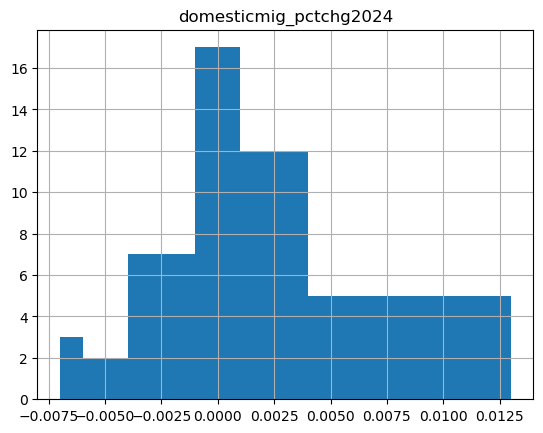

In [22]:
print(net_domesticmigr_df["domesticmig_pctchg2024"].describe())
bin_cutoff_list = [
    -0.007, -0.006, -0.004, -0.001, 0.001, 0.004, 0.006, 0.013
]
net_domesticmigr_df.hist(
    column="domesticmig_pctchg2024", bins=bin_cutoff_list
)

In [23]:
# Add cat_label, fill_color, and label_color columns to net_domesticmigr_df
fig3_fill_color_list = [
    "#de2d26", "#fc9272", "#fee0d2", "white", "#deebf7", "#9ecae1", "#3182bd"
]
fig3_label_color_list = [
    "white", "black", "black", "black", "black", "black", "white"
]
net_domesticmigr_plot_df = net_domesticmigr_df.copy()
net_domesticmigr_plot_df["cat_label"] = ""
net_domesticmigr_plot_df["fill_color"] = ""
net_domesticmigr_plot_df["label_color"] = ""
for bin in range(len(bin_cutoff_list) - 1):
    bin_min = bin_cutoff_list[bin]
    bin_max = bin_cutoff_list[bin + 1]
    if bin == 0:
        net_domesticmigr_plot_df["cat_label"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = f"Less than {(bin_max * 100):.1f}%"
        net_domesticmigr_plot_df["fill_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df["label_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = fig3_label_color_list[bin]
    elif ((bin > 0) and (bin < len(bin_cutoff_list) - 2)):
        net_domesticmigr_plot_df["cat_label"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = f"{(bin_min * 100):.1f}% to {(bin_max * 100):.1f}%"
        net_domesticmigr_plot_df["fill_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df["label_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] < bin_max)
        ] = fig3_label_color_list[bin]
    elif bin == len(bin_cutoff_list) - 2:
        net_domesticmigr_plot_df["cat_label"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min)
        ] = f"Greater than {(bin_min * 100):.1f}%"
        net_domesticmigr_plot_df["fill_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min)
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df["label_color"][
            (net_domesticmigr_plot_df["domesticmig_pctchg2024"] >= bin_min)
        ] = fig3_label_color_list[bin]

net_domesticmigr_plot_df

,state_str,state_abbrev,popestimate2023,domesticmig2024,domesticmig_pctchg2024,popestimate2022,domesticmig2023,domesticmig_pctchg2023,netdomesticmig_rank_2024,netdomesticmig_rank_2023,cat_label,fill_color,label_color
0,South Carolina,SC,5387830,68043,0.012629,5287935,80092,0.015146,1,1,,,
1,Idaho,ID,1971122,16383,0.008312,1944299,14730,0.007576,2,7,,,
2,Delaware,DE,1036423,8155,0.007868,1020625,9931,0.009730,3,2,,,
3,North Carolina,NC,10881189,82288,0.007562,10710793,98981,0.009241,4,3,,,
4,Tennessee,TN,7148304,48476,0.006781,7062217,60293,0.008537,5,4,,,
5,Nevada,NV,3214363,16853,0.005243,3176116,8174,0.002574,6,18,,,
6,Alabama,AL,5117673,26028,0.005086,5076181,29946,0.005899,7,10,,,
7,Montana,MT,1131302,5410,0.004782,1122095,9110,0.008119,8,6,,,
8,Arizona,AZ,7473027,34902,0.004670,7377566,35208,0.004772,9,15,,,
9,Arkansas,AR,3069463,13465,0.004387,3047704,17821,0.005847,10,11,,,


In [24]:
fig3_title = (
    "Figure 3. 2024 net domestic migration as percent of 2023 population"
)
# fig3_title = ""
output_file(
    "./images/fig3_net_domestic_migration_2024.html",
    title=fig3_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/AR-IndivBusTax25/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state domestic migration percent change data into gjson for each
# state
net_domesticmigr_plot_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["netmigr_pct_cat"] = net_domesticmigr_plot_df[
        net_domesticmigr_plot_df["state_abbrev"]==st_abbrev
    ]["cat_label"].iloc[0]
    state["properties"]["net_migr_pct_chg"] = net_domesticmigr_plot_df[
        net_domesticmigr_plot_df["state_abbrev"]==st_abbrev
    ]["domesticmig_pctchg2024"].iloc[0]

fig3_cat_labels = [
    "Less than -0.6%", "-0.6% to -0.4%", "-0.4% to -0.1%", "-0.1% to 0.1%",
    "0.1% to 0.4%", "0.4% to 0.6%", "Greater than 0.6%"
]

source_shapes = {}
for category in fig3_cat_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[
        item["properties"]["netmigr_pct_cat"]
    ]['features'].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig3 = figure(
    title=fig3_title,
    height=500,
    width=950,
    tools=TOOLS,
    # tooltips=[
    #     ("State", @state_names), ("Tax type", @tax_type)
    # ]
    # match_aspect = True,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig3.toolbar.logo = None
fig3.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=fig3_fill_color_list, factors=fig3_cat_labels
)
for category in fig3_cat_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig3.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'netmigr_pct_cat', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig3.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Pct chg category", "@netmigr_pct_cat"),
        ("2024 net domestic migration (%chg)", "@net_migr_pct_chg{0.00%}")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        net_domesticmigr_plot_df[
            net_domesticmigr_plot_df["state_abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig3.add_layout(state_labels)

# Legend properties
fig3.legend.click_policy = 'mute'
fig3.legend.location = "center_left"

note_text_list3 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated Nov. 21, 2025. ' +
        'Data are from US Census Bureau, U-Haul, United Van Lines. See also'
    ),
    (
        '      Tax Foundation, Loughead (2025).'
    )
]
for note_text in note_text_list3:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig3.add_layout(caption, 'below')

show(fig3)

Loading BokehJS ...

KeyError: ''

## 3. Create Figures 4 and 5

### 3.1. Figure 4. Rainy Day Fund and Total Reserves as Percentages of General-Fund Expenditures, Missouri and 50-State Median: 2000-2024

Get the Pew state rainy day fund data. This does not include District of Columbia. The 2023 data is now final. The 2024 data is labeled as "Projected" which means projected based on enacted legislation.

In [25]:
# Read in the Pew data on rainy day funds by year and state from worksheet
rain_totbal_path = (
    "https://github.com/OpenSourceEcon/AR-IndivBusTax25/blob/main/data/" +
    "Pew_ReservesData_2025.csv?raw=true"
)

In [26]:
# Create a DataFrame of just the rainy day funds in $ by state and by year
rain_dol_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
rain_dol_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,2500000,7500000,261000000,68000000,104000000,157000000,418700000,676600000,248000000,178700000,...,530200000,766200000,783700000,848200000,968100000,1184300000,1429000000,1978000000,2683100000,3199400000
Alaska,2734200000,2994800000,2114000000,2092500000,2155100000,2274200000,2267100000,3015200000,5601200000,8897900000,...,7108900000,4641300000,2532500000,2288000000,1378900000,1059900000,2625800000,2453500000,2884000000,2884000000
Arizona,407800000,391500000,65000000,13800000,13500000,160800000,501600000,677000000,218600000,2700000,...,460800000,461400000,457800000,743000000,978500000,974700000,982200000,1424000000,1476800000,1544800000
Arkansas,0,0,0,0,0,0,0,0,0,0,...,0,123400000,126600000,152500000,185000000,210000000,1212000000,1529600000,1814900000,1814900000
California,8665500000,1563800000,0,0,0,9112300000,10071400000,3014800000,0,0,...,7223600000,11250800000,20842000000,23001300000,20632100000,52453100000,76216800000,67571100000,41678800000,27500100000
Colorado,583400000,0,0,0,121800000,0,0,267000000,283500000,443800000,...,512700000,614500000,1366000000,1262000000,1823300000,3178000000,1612200000,2427300000,3169300000,2141100000
Connecticut,564000000,594700000,0,0,302200000,666100000,1112500000,1381700000,1381700000,1381700000,...,235600000,212900000,1185300000,2134900000,3074600000,3112000000,3313400000,3315800000,4105100000,4255200000
Delaware,114000000,126000000,128000000,129000000,136500000,148200000,161100000,175400000,182800000,186400000,...,214700000,221100000,231600000,240400000,252400000,252400000,280300000,316400000,328800000,348700000
Florida,1666100000,894000000,941000000,958900000,966400000,988200000,1069300000,1236800000,1344800000,273900000,...,1353700000,1384400000,1416500000,1483000000,1574200000,1674200000,2730200000,3140200000,4140400000,4440500000


In [27]:
# Create a DataFrame of just the rainy day funds balances as a percent of
# general fund expenditures by state and by year
rain_pct_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
rain_pct_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0.00048,0.00144,0.04901,0.01243,0.01897,0.02594,0.06015,0.08487,0.02880,0.02310,...,0.06790,0.09383,0.09435,0.09806,0.10400,0.12172,0.13413,0.147026,0.21022,0.23477
Alaska,1.20891,1.31738,0.88382,0.83844,0.92928,0.74449,0.69817,0.54775,1.02537,1.55229,...,1.29855,1.03188,0.56414,0.46802,0.28699,0.22861,0.48432,0.321429,0.51646,0.52325
Arizona,0.06783,0.06145,0.01025,0.00229,0.00207,0.02131,0.05721,0.06637,0.02178,0.00031,...,0.04844,0.04789,0.04667,0.06928,0.08671,0.07170,0.07620,0.090850,0.08528,0.09407
Arkansas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.02307,0.02304,0.02711,0.03217,0.03560,0.20721,0.253905,0.29263,0.28755
California,0.13032,0.02004,0.00000,0.00000,0.00000,0.11418,0.10996,0.02973,0.00000,0.00000,...,0.06311,0.09431,0.16706,0.16384,0.14104,0.32353,0.34289,0.346182,0.20077,0.11851
Colorado,0.09736,0.00000,0.00000,0.00000,0.02141,0.00000,0.00000,0.03789,0.03811,0.06008,...,0.05012,0.05894,0.12180,0.09817,0.14339,0.23846,0.09043,0.127570,0.18780,0.11330
Connecticut,0.05168,0.04975,0.00000,0.00000,0.02385,0.04862,0.07645,0.08952,0.08467,0.08222,...,0.01312,0.01201,0.06344,0.11074,0.16044,0.15517,0.15983,0.148908,0.18396,0.18311
Delaware,0.05076,0.05187,0.05216,0.05257,0.05345,0.05251,0.05065,0.05174,0.05343,0.05656,...,0.05486,0.05385,0.05624,0.05471,0.05592,0.05589,0.05542,0.053985,0.05276,0.05008
Florida,0.08980,0.04455,0.04910,0.04674,0.04510,0.04043,0.04110,0.04383,0.04854,0.01158,...,0.04639,0.04566,0.04450,0.04459,0.04789,0.04616,0.07159,0.064045,0.07526,0.07561


In [28]:
# Create a DataFrame of just the total balances and reserves in $ by state and
# by year
totbal_dol_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
        44, 45, 46, 47, 48, 49, 50, 51, 52
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
totbal_dol_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,103600000,74300000,280200000,180500000,450600000,821000000,1368100000,1191400000,467000000,284100000,...,715000000,916100000,1376800000,1822600000,1788400000,3004700000,4852300000,5214485000,5758700000,5620300000
Alaska,2734200000,2994800000,2114000000,2092500000,2181600000,2282800000,2267100000,3015200000,5601200000,7447100000,...,7108900000,4641300000,2532500000,2288000000,1378900000,1059900000,3264500000,2453500000,2884000000,2884000000
Arizona,611200000,404700000,65700000,206000000,373800000,799800000,1548100000,1055000000,219600000,-478000000,...,744600000,612300000,907400000,1700200000,1351000000,1869300000,5691600000,3951233000,2500800000,2376600000
Arkansas,0,0,0,0,0,0,0,0,0,0,...,177400000,123400000,126600000,447900000,188200000,1155700000,2810200000,2690700000,2513300000,2093500000
California,9139000000,3037000000,-2133300000,1607300000,3488800000,9633600000,10816300000,3900100000,2375700000,-5854700000,...,8203500000,12415500000,22226500000,26176300000,23807200000,56729600000,80493200000,78140300000,59679400000,45500700000
Colorado,798300000,469500000,137600000,224900000,346400000,335500000,908800000,516000000,327000000,443800000,...,512700000,614500000,1366000000,1262000000,1823300000,3178000000,3201800000,2427300000,3169300000,2141100000
Connecticut,564000000,594700000,0,0,302200000,666100000,1112500000,1381700000,1382000000,1382000000,...,235600000,212900000,1185300000,2505500000,3074600000,3112000000,3313400000,3315800000,4105100000,4255200000
Delaware,338000000,510000000,481700000,464100000,646000000,701300000,690600000,590900000,526000000,378500000,...,568000000,475000000,749800000,947500000,959400000,1833400000,2605400000,3039530000,3156300000,2852600000
Florida,2155900000,1382700000,1925100000,1641300000,3423600000,4558800000,6059300000,4670400000,1665700000,905300000,...,3245500000,2898900000,3062400000,3972700000,7926400000,15476000000,25533300000,24392300000,20545700000,11425500000


In [29]:
# Create a DataFrame of just the total balances and reserves as a percent of
# general fund expenditures by state and by year
totbal_pct_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
        70, 71, 72, 73, 74, 75, 76, 77, 78
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
totbal_pct_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0.01986,0.01425,0.05262,0.03298,0.08218,0.13567,0.19653,0.14945,0.05422,0.03673,...,0.09157,0.11218,0.16575,0.21072,0.19212,0.30881,0.45546,0.387597,0.45120,0.41241
Alaska,1.20891,1.31738,0.88382,0.83844,0.94071,0.74731,0.69817,0.54775,1.02537,1.29919,...,1.29855,1.03188,0.56414,0.46802,0.28699,0.22861,0.60213,0.321429,0.51646,0.52325
Arizona,0.10166,0.06353,0.01037,0.03419,0.05737,0.10600,0.17655,0.10342,0.02188,-0.05460,...,0.07828,0.06355,0.09251,0.15854,0.11972,0.13750,0.44157,0.252086,0.14441,0.14472
Arkansas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.03418,0.02307,0.02304,0.07961,0.03273,0.19589,0.48044,0.446641,0.40523,0.33170
California,0.13744,0.03891,-0.02779,0.02074,0.04570,0.12072,0.11809,0.03846,0.02307,-0.06438,...,0.07167,0.10408,0.17816,0.18646,0.16274,0.34990,0.36213,0.400331,0.28748,0.19608
Colorado,0.13322,0.07039,0.02058,0.03804,0.06089,0.05488,0.14088,0.07323,0.04395,0.06008,...,0.05012,0.05894,0.12180,0.09817,0.14339,0.23846,0.17959,0.127570,0.18780,0.11330
Connecticut,0.05168,0.04975,0.00000,0.00000,0.02385,0.04862,0.07645,0.08952,0.08468,0.08223,...,0.01312,0.01201,0.06344,0.12996,0.16044,0.15517,0.15983,0.148908,0.18396,0.18311
Delaware,0.15049,0.20996,0.19630,0.18911,0.25297,0.24849,0.21714,0.17431,0.15373,0.11485,...,0.14513,0.11568,0.18207,0.21562,0.21254,0.40595,0.51511,0.518614,0.50646,0.40966
Florida,0.11620,0.06891,0.10044,0.08001,0.15978,0.18653,0.23292,0.16552,0.06012,0.03826,...,0.11122,0.09560,0.09621,0.11944,0.24114,0.42671,0.66953,0.497486,0.37344,0.19454


In [30]:
rain_pct_50_df = rain_pct_df.loc["50-state", :].to_frame().reset_index()
rain_pct_50_df.rename(
    columns = {"index":"year", "50-state":"fraction"}, inplace = True
)
rain_pct_50_df["percent"] = 100 * rain_pct_50_df["fraction"]
rain_pct_50_df["series"] = "50-state median Rainy Day Fund"

rain_pct_ar_df = rain_pct_df.loc["Arkansas", :].to_frame().reset_index()
rain_pct_ar_df = rain_pct_ar_df.rename(
    columns = {"index":"year", "Arkansas":"fraction"}
)
rain_pct_ar_df["percent"] = 100 * rain_pct_ar_df["fraction"]
rain_pct_ar_df["series"] = "Arkansas Rainy Day Fund"

totbal_pct_50_df = \
    totbal_pct_df.loc["50-state", :].to_frame().reset_index()
totbal_pct_50_df = totbal_pct_50_df.rename(
    columns = {"index":"year", "50-state":"fraction"}
)
totbal_pct_50_df["percent"] = 100 * totbal_pct_50_df["fraction"]
totbal_pct_50_df["series"] = "50-state median total reserve balances"

totbal_pct_ar_df = totbal_pct_df.loc[
    "Arkansas", :
].to_frame().reset_index()
totbal_pct_ar_df = totbal_pct_ar_df.rename(
    columns = {'index':'year', "Arkansas":"fraction"}
)
totbal_pct_ar_df["percent"] = 100 * totbal_pct_ar_df["fraction"]
totbal_pct_ar_df["series"] = "Arkansas total reserve balances"

# Merge the four DataFrames to save the joint dataframe as a .csv
fig4_source_df = rain_pct_50_df[['year', 'percent']].rename(
    columns={'percent':'rain_50m_pct'}
)
fig4_source_df = pd.merge(
    fig4_source_df,
    rain_pct_ar_df[['year', 'percent']].rename(
        columns={'percent':'rain_ar_pct'}
    ),
    on='year', how='inner'
)
fig4_source_df = pd.merge(
    fig4_source_df,
    totbal_pct_50_df[['year', 'percent']].rename(
        columns={'percent':'totbal_50m_pct'}
    ),
    on='year', how='inner'
)
fig4_source_df = pd.merge(
    fig4_source_df,
    totbal_pct_ar_df[['year', 'percent']].rename(
        columns={'percent':'totbal_ar_pct'}
    ),
    on='year', how='inner'
)
# Set zeros to NaN
fig4_source_df = fig4_source_df.replace(0, np.nan)

fig4_source_df.to_csv('./data/fig4_source.csv', index=False)

fig4_source_df

,year,rain_50m_pct,rain_ar_pct,totbal_50m_pct,totbal_ar_pct
0,2000,4.127000,NaN,8.767000,NaN
1,2001,4.614000,NaN,7.148000,NaN
2,2002,1.656000,NaN,2.887000,NaN
3,2003,0.722000,NaN,2.656000,NaN
4,2004,1.844000,NaN,5.247000,NaN
5,2005,2.460000,NaN,9.017000,NaN
6,2006,4.553000,NaN,11.802000,NaN
7,2007,4.739000,NaN,11.328000,NaN
8,2008,4.835000,NaN,8.292000,NaN
9,2009,2.728000,NaN,4.583000,NaN


In [31]:
# Create Bokeh plot Fig 4: Arkansas Rainy Day fund and total reserves as
# a percentage of general fund expenditures: 2000-2025
fig4_title_lst = [
    ("Figure 4. Arkansas Rainy Day fund and total reserves as a"),
    ("percentage of general fund expenditures: 2000-2025"),
]
# fig4_title_lst = []
fig4_title_short = "Figure 4. AR Rainy Day fund and total reserves"
filename_fig4 = "fig4_ar_raintotbal_tseries.html"
output_file(
    os.path.join(image_dir, filename_fig4),
    title=fig4_title_short,
    mode="inline",
)
output_notebook()

# Format the tooltip
tooltips_fig4 = [
    ("Series:", "@series"),
    ("Year:", "@year"),
    ("Pct. of Gen. Fund Exps.:", "@fraction{0.0%}")
]

min_year = 2000
max_year = 2025
min_pct = 2.0
max_pct = 0.0
pct_buffer = 0.05
fig4_height = 500
fig4_width = 800

var_list = [rain_pct_ar_df, rain_pct_50_df, totbal_pct_ar_df, totbal_pct_50_df]
color_list = ["#3477A5", "#D5AB53", "#3477A5", "#D5AB53"]
marker_list = ["circle", "circle", "square", "square"]
legend_label_list = [
    "Rainy day fund, Arkansas",
    "Rainy day fund, 50-state median",
    "Total balances, Arkansas",
    "Total balances, 50-state median"
]
cds_list = []

for k, df in enumerate(var_list):
    min_pct = np.minimum(min_pct, df["percent"].min())
    max_pct = np.maximum(max_pct, df["percent"].max())
    cds_list.append(ColumnDataSource(df))

fig4 = figure(
    height=fig4_height,
    width=fig4_width,
    x_axis_label='Year',
    x_range=(min_year - 1, max_year + 1.6),
    y_axis_label='Percent of general fund expenditures',
    y_range=(min_pct - pct_buffer * (max_pct - min_pct),
             max_pct + pct_buffer * (max_pct - min_pct)),
    tools=["save", "help"],
    toolbar_location="right"
)
fig4.toolbar.logo = None

# Turn off any pan, drag, or scrolling ability
fig4.toolbar.active_drag = None
fig4.toolbar.active_scroll = None
fig4.toolbar.active_tap = None

# Set title font size and axes font sizes
fig4.xaxis.axis_label_text_font_size = '12pt'
fig4.xaxis.major_label_text_font_size = '12pt'
fig4.xaxis.major_label_text_color = '#434244'
fig4.yaxis.axis_label_text_font_size = '12pt'
fig4.yaxis.major_label_text_font_size = '12pt'
fig4.yaxis.major_label_text_color = '#434244'

# Modify tick intervals for X-axis and Y-axis
fig4.xaxis.ticker = SingleIntervalTicker(interval=2, num_minor_ticks=2)
fig4.xaxis.axis_line_color = '#434244'
fig4.xaxis.major_tick_line_color = '#434244'
fig4.xaxis.minor_tick_line_color = '#434244'
fig4.xgrid.ticker = SingleIntervalTicker(interval=2)
fig4.yaxis.ticker = SingleIntervalTicker(interval=10, num_minor_ticks=5)
fig4.yaxis.axis_line_color = '#434244'
fig4.yaxis.major_tick_line_color = '#434244'
fig4.yaxis.minor_tick_line_color = '#434244'
fig4.ygrid.ticker = SingleIntervalTicker(interval=10)

# Create lines and markers for time series
for k, yvar in enumerate(var_list):
    fig4.line(x='year', y='percent', source=cds_list[k], color=color_list[k],
              line_width=4, alpha=0.7)
    fig4.scatter(x='year', y='percent', source=cds_list[k], size=10,
                 line_width=1, line_color='black', fill_color=color_list[k],
                 marker=marker_list[k], line_alpha=0.7, fill_alpha=0.7,
                 legend_label=legend_label_list[k])

fig4.segment(x0=2024.4, y0=min_pct - pct_buffer * (max_pct - min_pct),
             x1=2024.4, y1=max_pct + pct_buffer * (max_pct - min_pct),
             color='#434244', line_dash='6 2', line_width=2)

label_projected = Label(
    x=2024.5, y=17.0, x_units='data', y_units='data', text='Projected',
    text_font_size='9pt', text_color='#434244'
)
fig4.add_layout(label_projected)

# Add legend
fig4.legend.location = 'top_center'
fig4.legend.border_line_width = 1
fig4.legend.border_line_color = '#434244'
fig4.legend.border_line_alpha = 1
fig4.legend.label_text_font_size = '12pt'
fig4.legend.label_text_color = '#434244'

# Add title and subtitle to the plot doing reverse loop through items in
# fig_title_lst
for title_line_str in fig4_title_lst[::-1]:
    fig4.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="15pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list4 = [
    (
        'Source: Pew Charitable Trusts, "Fiscal 50: Reserves and '+
        'Balances," Oct. 15, 2025, accessed Nov. 21, 2025.'
    )
]
for note_text in note_text_list4:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig4.add_layout(caption, 'below')

# Add the HoverTool to the figure
fig4.add_tools(
    HoverTool(
        tooltips=tooltips_fig4,
        visible=False
    )
)

show(fig4)

Loading BokehJS ...

### 3.2. Figure 5. Estimated 2025 Rainy Day Fund Balances and Total Reserves and Balances as Percentages of General-Fund Expenditures

In [32]:
rain_pct_2025_df = rain_pct_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
rain_pct_2025_df = rain_pct_2025_df.rename(
    columns = {"index": "state", "2025": "rain_frac"}
)
rain_pct_2025_df["rain_pct"] = 100 * rain_pct_2025_df["rain_frac"]
rain_pct_2025_df = rain_pct_2025_df.drop('rain_frac', axis=1)

rain_dol_2025_df = rain_dol_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
rain_dol_2025_df = rain_dol_2025_df.rename(
    columns = {"index": "state", "2025": "rain_dol"}
)

totbal_pct_2025_df = \
    totbal_pct_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
totbal_pct_2025_df = totbal_pct_2025_df.rename(
    columns = {"index": "state", "2025": "totbal_frac"}
)
totbal_pct_2025_df["totbal_pct"] = 100 * totbal_pct_2025_df["totbal_frac"]
totbal_pct_2025_df = totbal_pct_2025_df.drop('totbal_frac', axis=1)

totbal_dol_2025_df = \
    totbal_dol_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
totbal_dol_2025_df = totbal_dol_2025_df.rename(
    columns = {"index": "state", "2025": "totbal_dol"}
)

# Merge the four DataFrames
rain_totbal_pct_dol_2025_df = rain_pct_2025_df.copy()
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, rain_dol_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df["rain_color"] = "#D5AB53"
rain_totbal_pct_dol_2025_df["rain_color"][
    rain_totbal_pct_dol_2025_df["state"]=="Arkansas"
] = "#EED17E"
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, totbal_pct_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, totbal_dol_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df["totbal_color"] = "#3477A5"
rain_totbal_pct_dol_2025_df["totbal_color"][
    rain_totbal_pct_dol_2025_df["state"]=="Arkansas"
] = "#74AAC7"

# Create a new variable that is totbal_pct - rain_pct
rain_totbal_pct_dol_2025_df["totbal_rain_pct_dif"] = (
    rain_totbal_pct_dol_2025_df["totbal_pct"] -
    rain_totbal_pct_dol_2025_df["rain_pct"]
)

# Sort by total reserves balances percent
rain_totbal_pct_dol_2025_sorted_df = rain_totbal_pct_dol_2025_df.sort_values(
    by=['totbal_pct', 'rain_pct', 'state'], ascending=[True, True, True]
)

rain_totbal_pct_dol_2025_sorted_df.to_csv(
    os.path.join(data_dir, "fig5_source.csv"), index=False
)
rain_totbal_pct_dol_2025_sorted_df

,state,rain_pct,rain_dol,rain_color,totbal_pct,totbal_dol,totbal_color,totbal_rain_pct_dif
46,Washington,3.518,1255100000,#D5AB53,5.915,2110200000,#3477A5,2.397
12,Illinois,4.306,2347000000,#D5AB53,8.450,4606000000,#3477A5,4.144
38,Rhode Island,5.252,294700000,#D5AB53,8.596,482300000,#3477A5,3.344
19,Maryland,7.932,2184900000,#D5AB53,8.612,2372000000,#3477A5,0.680
13,Indiana,7.810,1795400000,#D5AB53,9.322,2143100000,#3477A5,1.512
40,South Dakota,9.326,242000000,#D5AB53,9.326,242000000,#3477A5,0.000
23,Mississippi,9.516,669000000,#D5AB53,9.516,669000000,#3477A5,0.000
28,New Hampshire,10.317,211500000,#D5AB53,10.317,211500000,#3477A5,0.000
5,Colorado,11.330,2141100000,#D5AB53,11.330,2141100000,#3477A5,0.000
43,Utah,9.313,1186600000,#D5AB53,11.347,1445700000,#3477A5,2.034


In [33]:
# Create Bokeh plot Fig 5: State 2025 Rainy day Fund Balances and Total Fund
# Balances as Percent of General Fund Expenditures
fig5_title_lst = [
    ("Figure 5. State 2025 Rainy day Fund Balances and Total"),
    ("Fund Balances as Percent of General Fund Expenditures")
]
# fig5_title_lst = []
fig5_title_short = "Figure 5. State 2025 Rainy Day fund and Total Reserves"
filename_fig5 = "fig5_rain_totbal_pct_2025.html"
output_file(
    os.path.join(image_dir, filename_fig5),
    title=fig5_title_short,
    mode="inline",
)
output_notebook()

states = rain_totbal_pct_dol_2025_sorted_df['state'].tolist()
legend_label_list_fig5 = ["Rainy day fund", "Total reserves and balances"]
rain_totbal_pct_dol_2025_cds = \
    ColumnDataSource(rain_totbal_pct_dol_2025_sorted_df)

min_pct = rain_totbal_pct_dol_2025_sorted_df['rain_pct'].min()
max_pct = rain_totbal_pct_dol_2025_sorted_df['totbal_pct'].max()
pct_buffer = 0.05
fig5_height = 900
fig5_width = 550

fig5 = figure(
    height=fig5_height,
    width=fig5_width,
    y_range=states,
    x_axis_label='Percentage of general fund expenditures',
    x_range=(min_pct - pct_buffer * (max_pct - min_pct),
             max_pct + pct_buffer * (max_pct - min_pct)),
    tools=["save", "help"],
    toolbar_location="right"
)
fig5.toolbar.logo = None

# Turn off any pan, drag, or scrolling ability
fig5.toolbar.active_drag = None
fig5.toolbar.active_scroll = None
fig5.toolbar.active_tap = None

# Set title font size and axes font sizes
fig5.xaxis.axis_label_text_font_size = '11pt'
fig5.xaxis.major_label_text_font_size = '11pt'
fig5.xaxis.major_label_text_color = '#434244'
fig5.yaxis.axis_label_text_font_size = '9pt'
fig5.yaxis.major_label_text_font_size = '9pt'
fig5.yaxis.major_label_text_color = '#434244'

# Modify tick intervals for X-axis and Y-axis
fig5.xaxis.ticker = SingleIntervalTicker(interval=10, num_minor_ticks=5)
fig5.xaxis.axis_line_color = '#434244'
fig5.xaxis.major_tick_line_color = '#434244'
fig5.xaxis.minor_tick_line_color = '#434244'
fig5.xgrid.ticker = SingleIntervalTicker(interval=10)
fig5.yaxis.axis_line_color = '#434244'
fig5.yaxis.major_tick_line_color = '#434244'
fig5.yaxis.minor_tick_line_color = '#434244'

fig5.hbar_stack(
    ['rain_pct', 'totbal_rain_pct_dif'], y='state', height=0.9,
    color=['rain_color', 'totbal_color'],
    source=rain_totbal_pct_dol_2025_cds, legend_label=legend_label_list_fig5
)

# Add information on hover
tooltips_fig5 = [
    ('State', '@state'),
    ('Rainy day fund % exps.','@rain_pct{0.0}' + '%'),
    ('Total balances % exps.','@totbal_pct{0.0}' + '%'),
]
fig5.add_tools(HoverTool(tooltips=tooltips_fig5, visible=False))

# Add legend
fig5.legend.location = (190, 240)
fig5.legend.border_line_width = 1
fig5.legend.border_line_color = '#434244'
fig5.legend.border_line_alpha = 1
fig5.legend.label_text_color = '#434244'
fig5.legend.label_text_font_size = '11pt'
fig5.legend.label_text_color = '#434244'
fig5.y_range.range_padding = 0.02

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig5_title_lst[::-1]:
    fig5.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list5 = [
    (
        'Source: Pew Charitable Trusts, "Fiscal 50: Reserves and '+
        'Balances,"'
    ),
    ('        Oct. 15, 2025, accessed Nov. 21, 2025.'),
    (
        'Note: For states in which the blue bar is not visible for total ' +
        'balances'
    ),
    (
        '        and reserves, the value equals the rainy day fund balance'
    ),
    (
        '        percentage.'
    )
]
for note_text in note_text_list5:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig5.add_layout(caption, 'below')

show(fig5)

Loading BokehJS ...

## 4. Moving to a flat individual income tax
Arkansas' individual income tax code is likely the most complicated in the country by almost any metric.
- Two sets of individual income tax brackets
- Complicated mapping from marginal tax rates to long tables
- Tax backets, low income credit, and high income reduction adjusted annually by CPI, but no more than 3% (can cause income ranges to be $200 instead of $100)
- Lump sum retirement distributions
- Complicated capital gains deduction
- Two different child and dependant tax credits
- Texarkana

Complexity can be a tax on citizens.

Arkansas has two individual income tax rate schedules depending on if you make more than $92,500 in Arkansas adjusted gross income (AGI).


**Arkansas 2025 individual income tax rates and brackets for Arkansas AGI < $92,300, as of July 2025**

| Income range |  Marginal tax rate  |
| :--- | :---: |
| $0 - $5,499       | 0.0% |
| $5,500 - $10,899  | 2.0% |
| $10,900 - $15,599 | 3.0% |
| $15,600 - $25,699 | 3.4% |
| $25,700 - $92,300 | 3.9% |

**Arkansas 2025 individual income tax rates and brackets for Arkansas AGI >= $92,300, as of July 2025**

| Income range |  Marginal tax rate  |
| :--- | :---: |
| $0 - $4,600      | 2.0% |
| $4,601 and above | 3.9% |

- Arkansas' standard deduction is much smaller than the federal standard deduction.
- Bracket levels adjusted for inflation each year. Inflation-adjusted bracket levels for 2025 are shown.

### 4.1. Figures 6a and 6b. Arkansas current progressive marginal tax rates on employment income versus proposed 3.4% and 3.0% flat tax rates

In [34]:
# Create Bokeh plot of Figure 6 current vs proposed flat tax marginal rates
fig6a_title_lst = (
    (
        "Figure 6a. Arkansas 2025 progressive marginal tax rates on " +
        "net employment income"
    ),
    ("< $92,300versus proposed 3.4% and 3.0% flat tax")
)
# fig6_title_lst = ""
fig6a_title_short = "Figure 6a. AR 2025 progressive vs flat tax rates"
filename_fig6a = "fig6a_CurrReformTaxRates.html"
output_file(
    os.path.join(image_dir, filename_fig6a),
    title=fig6a_title_short,
    mode="inline",
)
output_notebook()

# Create data objects for plot
flat_tax_rate1 = 0.034
flat_tax_rate2 = 0.030
curr_tax_rates = [0.0, 0.020, 0.030, 0.034, 0.039]
min_marg_tax_rate_toplot = -0.003
max_marg_tax_rate_toplot = 0.046

# # Cheap trick to get the y-axis to only show from min_marg_tax_rate_toplot to
# # max_margin_tax_rate_toplot
# flat_tax_rate_adj = flat_tax_rate1 - min_marg_tax_rate_toplot
# curr_tax_rates_adj = [x - min_marg_tax_rate_toplot for x in curr_tax_rates]
# min_marg_tax_rate_toplot_adj = (min_marg_tax_rate_toplot -
#                                 min_marg_tax_rate_toplot)
# max_marg_tax_rate_toplot_adj = (max_marg_tax_rate_toplot -
#                                 min_marg_tax_rate_toplot)

# Create label for under each bar on the x-axis
bar_under_labels = [
    "$0 to $5.5k", "$5.5k to $10.9k", "$10.9k to $15.6k", "$15.6k to $25.7k",
    "$25.7k to $92.3k"
]

fig6a = figure(
    height=550,
    width=800,
    x_axis_label="Tax bracket AR taxable income ranges",
    y_axis_label="Statutory marginal tax rate",
    x_range=bar_under_labels,
    y_range=(min_marg_tax_rate_toplot, max_marg_tax_rate_toplot),
    tools=["save", "help"],
    toolbar_location="right"
)
fig6a.title.text_font_size = "11pt"
fig6a.toolbar.logo = None

# Change x_axis_label and y_axis_label font sizes
fig6a.xaxis.axis_label_text_font_size = '12pt'
fig6a.xaxis.major_label_text_font_size = '11pt'
# fig6a.xaxis.major_label_text_color = '#434244'
fig6a.yaxis.axis_label_text_font_size = '12pt'
fig6a.yaxis.major_label_text_font_size = '11pt'
# fig6a.yaxis.major_label_text_color = '#434244'

vbar_curr = fig6a.vbar(
    x=bar_under_labels, top=curr_tax_rates, color="steelblue", width=0.7,
    border_radius=8
)
fig6a.xgrid.grid_line_color = None

# Dashed horizontal line at flat tax 0.035 or 3.5% with fill in shading below
flat_dash1 = fig6a.line(
    x=[0, 5],
    y=[flat_tax_rate1, flat_tax_rate1],
    color="darkblue",
    line_width=3,
    line_dash="dashed",
    alpha=0.5,
)
fig6a.vbar(
    x=flat_tax_rate1, top=flat_tax_rate1, color="powderblue", width=10.0,
    level='underlay'
)

# Dashed horizontal line at flat tax 0.030 or 3.0%
flat_dash2 = fig6a.line(
    x=[0, 5],
    y=[flat_tax_rate2, flat_tax_rate2],
    color="darkblue",
    line_width=3,
    line_dash="dashed",
    alpha=0.5,
)

# # Add minor ticks only at every 0.005 interval but with not labels on the y-axis
# fig6.yaxis.ticker = FixedTicker(ticks=[0.0, 0.005, 0.01, 0.015, 0.02, 0.025,
#                                    0.03, 0.035, 0.04, 0.045, 0.05])
# Add custom y-axis major tick labels
fig6a.yaxis.major_label_overrides = {
    0.000: '0.0%', 0.005: '0.5%', 0.010: '1.0%', 0.015: '1.5%', 0.020: '2.0%',
    0.025: '2.5%', 0.030: '3.0%', 0.035: '3.5%', 0.040: '4.0%', 0.045: '4.5%'
}
fig6a.yaxis.minor_tick_line_color = None  # turn off y-axis minor ticks

# Add column height in percent at top center inside of each bar
label_bar1 = Label(
    x=0.42, y=0.0006, text='0.0%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='darkblue'
)
fig6a.add_layout(label_bar1)
label_bar2 = Label(
    x=1.42, y=0.0155, text='2.0%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig6a.add_layout(label_bar2)
label_bar3 = Label(
    x=2.42, y=0.0255, text='3.0%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig6a.add_layout(label_bar3)
label_bar4 = Label(
    x=3.42, y=0.0346, text='3.4%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='darkblue'
)
fig6a.add_layout(label_bar4)
label_bar5 = Label(
    x=4.42, y=0.0345, text='3.9%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig6a.add_layout(label_bar5)
label_flat1 = Label(
    x=0.5, y=0.0342, text='3.4% flat tax rate', x_units='data',
    y_units='data', text_font_size='12pt', text_color='darkblue'
)
fig6a.add_layout(label_flat1)
label_flat2 = Label(
    x=0.5, y=0.0302, text='3.0% flat tax rate', x_units='data',
    y_units='data', text_font_size='12pt', text_color='darkblue'
)
fig6a.add_layout(label_flat2)

# Add legend
legend = Legend(
    items=[
        ("Current policy progressive tax rates", [vbar_curr]),
        ("Proposed 3.4% flat tax rate", [flat_dash1]),
        ("Proposed 3.0% flat tax rate", [flat_dash2])
    ],
    location="center",
)
fig6a.add_layout(legend, "above")
fig6a.legend.orientation = "horizontal"
fig6a.legend.spacing = 20

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig6a_title_lst[::-1]:
    fig6a.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list6a = [
    (
        'Note: These tax rates and net income brackets apply to net income ' +
        'less than $92,300.'
    )
]
for note_text in note_text_list6a:
    caption = Title(
        text=note_text, align='left', text_font_size='3mm',
        text_font_style='italic', text_color='#434244'
    )
    fig6a.add_layout(caption, 'below')

show(fig6a)

Loading BokehJS ...

In [35]:
# Create Bokeh plot of Figure 6b current vs proposed flat tax marginal rates
fig6b_title_lst = (
    ("Figure 6b. Arkansas 2025 progressive marginal tax rates on net"),
    ("employment income > $92,300 versus proposed 3.4% and 3.0% flat tax")
)
# fig6b_title_lst = ""
fig6b_title_short = "Figure 6b. AR 2025 progressive vs flat tax rate"
filename_fig6b = "fig6b_CurrReformTaxRates.html"
output_file(
    os.path.join(image_dir, filename_fig6b),
    title=fig6b_title_short,
    mode="inline",
)
output_notebook()

# Create data objects for plot
flat_tax_rate1 = 0.034
flat_tax_rate2 = 0.030
curr_tax_rates = [0.020, 0.039]
min_marg_tax_rate_toplot = -0.003
max_marg_tax_rate_toplot = 0.046

# # Cheap trick to get the y-axis to only show from min_marg_tax_rate_toplot to
# # max_margin_tax_rate_toplot
# flat_tax_rate_adj = flat_tax_rate1 - min_marg_tax_rate_toplot
# curr_tax_rates_adj = [x - min_marg_tax_rate_toplot for x in curr_tax_rates]
# min_marg_tax_rate_toplot_adj = (min_marg_tax_rate_toplot -
#                                 min_marg_tax_rate_toplot)
# max_marg_tax_rate_toplot_adj = (max_marg_tax_rate_toplot -
#                                 min_marg_tax_rate_toplot)

# Create label for under each bar on the x-axis
bar_under_labels = ["$0 to $4.6k", ">=$4.6k"]

fig6b = figure(
    height=550,
    width=800,
    x_axis_label="Tax bracket AR taxable income ranges",
    y_axis_label="Statutory marginal tax rate",
    x_range=bar_under_labels,
    y_range=(min_marg_tax_rate_toplot, max_marg_tax_rate_toplot),
    tools=["save", "help"],
    toolbar_location="right"
)
fig6b.title.text_font_size = "11pt"
fig6b.toolbar.logo = None

# Change x_axis_label and y_axis_label font sizes
fig6b.xaxis.axis_label_text_font_size = '12pt'
fig6b.xaxis.major_label_text_font_size = '11pt'
# fig6b.xaxis.major_label_text_color = '#434244'
fig6b.yaxis.axis_label_text_font_size = '12pt'
fig6b.yaxis.major_label_text_font_size = '11pt'
# fig6b.yaxis.major_label_text_color = '#434244'

vbar_curr = fig6b.vbar(
    x=bar_under_labels, top=curr_tax_rates, color="steelblue", width=0.7,
    border_radius=8
)
fig6b.xgrid.grid_line_color = None

# Dashed horizontal line at flat tax 0.034 or 3.4% with fill in shading below
flat_dash1 = fig6b.line(
    x=[0, 5],
    y=[flat_tax_rate1, flat_tax_rate1],
    color="darkblue",
    line_width=3,
    line_dash="dashed",
    alpha=0.5,
)
fig6b.vbar(
    x=flat_tax_rate1, top=flat_tax_rate1, color="powderblue", width=10.0,
    level='underlay'
)

# Dashed horizontal line at flat tax 0.030 or 3.0%
flat_dash2 = fig6b.line(
    x=[0, 5],
    y=[flat_tax_rate2, flat_tax_rate2],
    color="darkblue",
    line_width=3,
    line_dash="dashed",
    alpha=0.5,
)

# # Add minor ticks only at every 0.005 interval but with not labels on the y-axis
# fig6b.yaxis.ticker = FixedTicker(ticks=[0.0, 0.005, 0.01, 0.015, 0.02, 0.025,
#                                    0.03, 0.035, 0.04, 0.045, 0.05])
# Add custom y-axis major tick labels
fig6b.yaxis.major_label_overrides = {
    0.000: '0.0%', 0.005: '0.5%', 0.010: '1.0%', 0.015: '1.5%', 0.020: '2.0%',
    0.025: '2.5%', 0.030: '3.0%', 0.035: '3.5%', 0.040: '4.0%', 0.045: '4.5%'
}
fig6b.yaxis.minor_tick_line_color = None  # turn off y-axis minor ticks


# Add column height in percent at top center inside of each bar
label_bar1 = Label(
    x=0.43, y=0.0165, text='2.0%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig6b.add_layout(label_bar1)
label_bar2 = Label(
    x=1.45, y=0.0358, text='3.9%', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig6b.add_layout(label_bar2)
label_flat1 = Label(
    x=0.5, y=0.0342, text='3.4% flat tax rate', x_units='data',
    y_units='data', text_font_size='12pt', text_color='darkblue'
)
fig6b.add_layout(label_flat1)
label_flat2 = Label(
    x=0.5, y=0.0302, text='3.0% flat tax rate', x_units='data',
    y_units='data', text_font_size='12pt', text_color='darkblue'
)
fig6b.add_layout(label_flat2)

# Add legend
legend = Legend(
    items=[
        ("Current policy progressive tax rates", [vbar_curr]),
        ("Proposed 3.4% flat tax rate", [flat_dash1]),
        ("Proposed 3.0% flat tax rate", [flat_dash2])
    ],
    location="center",
)
fig6b.add_layout(legend, "above")
fig6b.legend.orientation = "horizontal"
fig6b.legend.spacing = 20

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig6b_title_lst[::-1]:
    fig6b.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list6b = [
    (
        'Note: These tax rates and net income brackets apply to net income ' +
        'greater than $92,300.'
    )
]
for note_text in note_text_list6b:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig6b.add_layout(caption, 'below')


show(fig6b)

Loading BokehJS ...

### 4.2. Figure 7a. 2025 Arkansas standard deductions by filer type plus proposed extra Arkansas standard deduction corresponding to 3.4% flat tax

In [36]:
# Create Bokeh plot of Figure 7b. Current 2025 Arkansas standard deduction
# amounts by filer type plus proposed extra Missouri standard deduction
# corresponding to 3.0% flat tax rate
fig7b_title_lst = (
    ("Figure 7b. Current 2025 Arkansas standard deduction amounts by filer " +
    "type"),
    (
        "plus proposed extra Arkansas standard deduction corresponding to " +
        "3.0% flat tax rate"
    )
)
# fig7b_title_lst = ""
fig7b_title_short = (
    "Figure 7b. 2025 AR current and proposed standard deductions, 3.0% flat " +
    "tax"
)
filename_fig7b = "fig7b_CurrReformAR_StdDeduct_30.html"
output_file(
    os.path.join(image_dir, filename_fig7b),
    title=fig7b_title_short,
    mode="inline",
)
output_notebook()

# Create standard deduction by filer type data for plot
filertypes7b = [
    "Married filing \n jointly", "Single", "Married filing \n separately",
    "Head of \n household", "Qualifying \n surviving spouse"
]
laws7ba = [
    'Curr AR std. deduction', 'Extra AR std. deduction'
]
laws7bb = [
    '2025 curr AR std. deduction', 'Proposed extra AR std. deduction'
]

data7b = {
    'filer_types': filertypes7b,
    'Curr AR std. deduction': [4_820, 2_410, 2_410, 2_410, 2_410],
    'Extra AR std. deduction': [2_000, 4_340, 4_340, 4_340, 4_340]
}
palette7b = ["lightskyblue", "darkblue"]

# This creates [("Married", "Federal std deduction"),
# ("Married", "Extra MO deduction"), ("Single", "Federal std deduction"),
# ("Single", "Extra MO deduction"), ... ]
x7b = [ (filertype, law) for filertype in filertypes7b for law in laws7ba]
# like an hstack for a tuple
std_deducts7b = sum(
    zip(data7b['Curr AR std. deduction'], data7b['Extra AR std. deduction']), ()
)
std_deducts7b_strfmt = ['${:,.0f}'.format(x) for x in std_deducts7b]

source7b = ColumnDataSource(
    data=dict(
        x=x7b, pers_exempts=std_deducts7b,
        std_deducts_strfmt=std_deducts7b_strfmt
    )
)

fig7b = figure(
    x_range=filertypes7b,
    y_range=(0, 8_900),
    height=550,
    width=850,
    x_axis_label="Filing status",
    y_axis_label="Standard Deduction",
    tools=["save", "help"],
    toolbar_location="right"
)
fig7b.title.text_font_size = "11pt"
fig7b.toolbar.logo = None

vbars7b = fig7b.vbar_stack(
    laws7ba, x='filer_types', width=0.85, source=data7b, color=palette7b,
    legend_label=laws7bb, line_color="white", border_radius=5
)

label_bar1_cur = Label(
    x=0.30, y=4_000, text='$4,820', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig7b.add_layout(label_bar1_cur)

label_bar1_ref = Label(
    x=0.29, y=6_000, text='+$2,000', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig7b.add_layout(label_bar1_ref)

label_bar1_tot = Label(
    x=0.28, y=6_880, text='$6,820', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig7b.add_layout(label_bar1_tot)

label_bar2_cur = Label(
    x=1.30, y=1_750, text='$2,410', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig7b.add_layout(label_bar2_cur)

label_bar2_ref = Label(
    x=1.29, y=6_000, text='+$4,340', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig7b.add_layout(label_bar2_ref)

label_bar2_tot = Label(
    x=1.28, y=6_880, text='$6,750', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig7b.add_layout(label_bar2_tot)

label_bar3_cur = Label(
    x=2.30, y=1_750, text='$2,410', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig7b.add_layout(label_bar3_cur)

label_bar3_ref = Label(
    x=2.29, y=6_000, text='+$4,340', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig7b.add_layout(label_bar3_ref)

label_bar3_tot = Label(
    x=2.28, y=6_880, text='$6,750', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig7b.add_layout(label_bar3_tot)

label_bar4_cur = Label(
    x=3.30, y=1_750, text='$2,410', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig7b.add_layout(label_bar4_cur)

label_bar4_ref = Label(
    x=3.29, y=6_000, text='+$4,340', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig7b.add_layout(label_bar4_ref)

label_bar4_tot = Label(
    x=3.28, y=6_880, text='$6,750', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig7b.add_layout(label_bar4_tot)

label_bar5_cur = Label(
    x=4.30, y=1_750, text='$2,410', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig7b.add_layout(label_bar5_cur)

label_bar5_ref = Label(
    x=4.29, y=6_000, text='+$4,340', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig7b.add_layout(label_bar5_ref)

label_bar5_tot = Label(
    x=4.28, y=6_880, text='$6,750', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig7b.add_layout(label_bar5_tot)

# Add custom y-axis major tick labels
fig7b.yaxis.ticker = SingleIntervalTicker(interval=1_000)
fig7b.yaxis.major_label_overrides = {
    1_000: '$1.0k', 2_000: '$2.0k', 3_000: '$3.0k', 4_000: '$4.0k',
    5_000: '$5.0k', 6_000: '$6.0k', 7_000: '$7.0k', 8_000: '$8.0k'
}
fig7b.yaxis.minor_tick_line_color = None  # turn off y-axis minor ticks

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig7b_title_lst[::-1]:
    fig7b.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Set the legend position
fig7b.legend.location = "top_center"

show(fig7b)

Loading BokehJS ...

### 4.3. Figure 8. 2025 federal standard deductions by filer type plus proposed extra Missouri standard deduction corresponding to 3.5% flat tax

In [37]:
# Create Bokeh plot of Figure 8. 2025 federal standard deductions by filer type
# plus proposed extra Missouri standard deduction corresponding to 3.5% flat
# tax rate
fig8_title_lst = (
    ("Figure 8. 2025 federal standard deductions by filer type plus proposed"),
    (
        "extra Missouri standard deduction corresponding to 3.5% flat " +
        "tax rate"
    )
)
# fig8_title_lst = ""
fig8_title_short = (
    "Figure 8. 2025 federal and proposed MO standard deduction, 3.5% flat tax"
)
filename_fig8 = "fig8_CurrReformMO_StdDeduct_3_5.html"
output_file(
    os.path.join(image_dir, filename_fig8),
    title=fig8_title_short,
    mode="inline",
)
output_notebook()

# Create standard deduction by filer type data for plot
filertypes8 = [
    "Married filing \n jointly", "Single", "Married filing \n separately",
    "Head of \n household", "Qualifying \nsurviving spouse"
]
laws8a = [
    'Federal std deduction', 'Extra MO deduction'
]
laws8b = [
    '2025 federal standard deduction', 'Proposed extra MO standard deduction'
]

data8 = {
    'filer_types': filertypes8,
    'Federal std deduction': [31_500, 15_750, 15_750, 23_625, 31_500],
    'Extra MO deduction': [2_400, 2_400, 2_400, 2_400, 2_400]
}
palette8 = ["lightskyblue", "darkblue"]

# This creates [("Married", "Federal std deduction"), ("Married", "Extra MO deduction"),
# ("Single", "Federal std deduction"), ("Single", "Extra MO deduction"), ... ]
x8 = [ (filertype, law) for filertype in filertypes8 for law in laws8a]
# like an hstack for a tuple
std_deducts8 = sum(
    zip(data8['Federal std deduction'], data8['Extra MO deduction']), ()
)
std_deducts8_strfmt = ['${:,.0f}'.format(x) for x in std_deducts8]

source8 = ColumnDataSource(
    data=dict(
        x=x8, std_deducts=std_deducts8, std_deducts_strfmt=std_deducts8_strfmt
    )
)

fig8 = figure(
    x_range=filertypes8,
    y_range=(0, 42_000),
    height=550,
    width=800,
    x_axis_label="Filing status",
    y_axis_label="Standard deduction",
    tools=["save", "help"],
    toolbar_location="right"
)
fig8.title.text_font_size = "11pt"
fig8.toolbar.logo = None

# Change x_axis_label and y_axis_label font sizes
fig8.xaxis.axis_label_text_font_size = '12pt'
fig8.xaxis.major_label_text_font_size = '11pt'
# fig8.xaxis.major_label_text_color = '#434244'
fig8.yaxis.axis_label_text_font_size = '12pt'
fig8.yaxis.major_label_text_font_size = '11pt'
# fig8.yaxis.major_label_text_color = '#434244'

vbars8 = fig8.vbar_stack(
    laws8a, x='filer_types', width=0.85, source=data8, color=palette8,
    legend_label=laws8b, line_color="white", border_radius=5
)

label_bar1_cur = Label(
    x=0.30, y=28_900, text='$31,500', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig8.add_layout(label_bar1_cur)

label_bar1_ref = Label(
    x=0.29, y=31_800, text='+$2,400', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig8.add_layout(label_bar1_ref)

label_bar1_tot = Label(
    x=0.28, y=34_600, text='$33,900', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig8.add_layout(label_bar1_tot)

label_bar2_cur = Label(
    x=1.30, y=13_000, text='$15,750', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig8.add_layout(label_bar2_cur)

label_bar2_ref = Label(
    x=1.29, y=16_100, text='+$2,400', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig8.add_layout(label_bar2_ref)

label_bar2_tot = Label(
    x=1.28, y=18_800, text='$18,150', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig8.add_layout(label_bar2_tot)

label_bar3_cur = Label(
    x=2.30, y=13_000, text='$15,750', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig8.add_layout(label_bar3_cur)

label_bar3_ref = Label(
    x=2.29, y=16_100, text='+$2,400', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig8.add_layout(label_bar3_ref)

label_bar3_tot = Label(
    x=2.28, y=18_800, text='$18,150', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig8.add_layout(label_bar3_tot)

label_bar4_cur = Label(
    x=3.30, y=20_900, text='$23,625', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig8.add_layout(label_bar4_cur)

label_bar4_ref = Label(
    x=3.29, y=23_900, text='+$2,400', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig8.add_layout(label_bar4_ref)

label_bar4_tot = Label(
    x=3.28, y=26_700, text='$26,025', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig8.add_layout(label_bar4_tot)

label_bar5_cur = Label(
    x=4.30, y=28_900, text='$31,500', x_units='data', y_units='data',
    text_font_size='12pt', text_color='black'
)
fig8.add_layout(label_bar5_cur)

label_bar5_ref = Label(
    x=4.29, y=31_800, text='+$2,400', x_units='data', y_units='data',
    text_font_size='12pt', text_color='white'
)
fig8.add_layout(label_bar5_ref)

label_bar5_tot = Label(
    x=4.28, y=34_600, text='$33,900', x_units='data', y_units='data',
    text_font_size='14pt', text_color='black'
)
fig8.add_layout(label_bar5_tot)

# Add custom y-axis major tick labels
fig8.yaxis.major_label_overrides = {
    5_000: '$5k', 10_000: '$10k', 15_000: '$15k', 20_000: '$20k',
    25_000: '$25k', 30_000: '$30k', 35_000: '$35k', 40_000: '$40k'
}
fig8.yaxis.minor_tick_line_color = None  # turn off y-axis minor ticks

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig8_title_lst[::-1]:
    fig8.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Set the legend position
fig8.legend.location = "top_center"

show(fig8)

Loading BokehJS ...

### 4.4. Effects of the 3.4% flat tax reform on Arkansas filers

### 4.4.1. Define the 12 filer types
These 12 filer types are detailed in the appendix of the paper.

#### 4.4.1.1. Define the three single filer types
Single, no kids, low income (household before-tax income = $13,000)

In [38]:
situation_sgl_low = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "0"},
            "employment_income": {"2025": "13000"},
            "medical_out_of_pocket_expenses": {"2025": "200"},
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "broadband_cost": {"2025": "400"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "5000"},
            "phone_cost": {"2025": "500"},
            "spm_unit_id": {"2025": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Single no kids, middle income (household before-tax income = $40,000)

In [39]:
situation_sgl_mid = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "employment_income": {"2025": "40000"},
            "medical_out_of_pocket_expenses": {"2025": "1000"},
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "broadband_cost": {"2025": "700"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "15000"},
            "phone_cost": {"2025": "1200"},
            "spm_unit_id": {"2025": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Single, no kids, high income (household before-tax income = $90,000)

In [40]:
situation_sgl_high = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "8000"},
            "employment_income": {"2025": "90000"},
            "medical_out_of_pocket_expenses": {"2025": "2000"},
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "broadband_cost": {"2025": "1200"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "30000"},
            "phone_cost": {"2025": "2000"},
            "spm_unit_id": {"2025": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

#### 4.4.1.2. Define the three head of household filer types

Head of household, 2 kids, low income (household before-tax income = $20,000)

In [41]:
situation_hoh_low = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "0"},
            "employment_income": {"2025": "20000"},
            "medical_out_of_pocket_expenses": {"2025": "500"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "500"},
            "childcare_expenses": {"2025": "1000"},
            "housing_cost": {"2025": "9000"},
            "phone_cost": {"2025": "600"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Head of household, 2 kids, middle income (household before-tax income = $60,000)

In [42]:
situation_hoh_mid = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "employment_income": {"2025": "60000"},
            "medical_out_of_pocket_expenses": {"2025": "2000"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "800"},
            "childcare_expenses": {"2025": "2000"},
            "housing_cost": {"2025": "20000"},
            "phone_cost": {"2025": "1000"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Head of household, 2 kids, high income (household before-tax income = $150,000)

In [43]:
situation_hoh_high = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "15000"},
            "employment_income": {"2025": "150000"},
            "medical_out_of_pocket_expenses": {"2025": "3000"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "1200"},
            "childcare_expenses": {"2025": "3000"},
            "housing_cost": {"2025": "36000"},
            "phone_cost": {"2025": "1800"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

#### 4.4.1.3. Define the six married filing jointly filer types

Married filing jointly, 0 kids, low income (household before-tax income = $22,000)

In [44]:
situation_mar_0_low = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "0"},
            "employment_income": {"2025": "12000"},
            "medical_out_of_pocket_expenses": {"2025": "400"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "10000"},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "broadband_cost": {"2025": "500"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "6000"},
            "phone_cost": {"2025": "800"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Married filing jointly, 0 kids, middle income (household before-tax income = $60,000)

In [45]:
situation_mar_0_mid = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "employment_income": {"2025": "35000"},
            "medical_out_of_pocket_expenses": {"2025": "1800"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "25000"},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "broadband_cost": {"2025": "900"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "18000"},
            "phone_cost": {"2025": "1200"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Married filing jointly, 0 kids, high income (household before-tax income = $160,000)

In [46]:
situation_mar_0_high = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "16000"},
            "employment_income": {"2025": "90000"},
            "medical_out_of_pocket_expenses": {"2025": "3000"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "70000"},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "broadband_cost": {"2025": "1200"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "36000"},
            "phone_cost": {"2025": "2000"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Married filing jointly, 2 kids, low income (household before-tax income = $25,000)

In [47]:
situation_mar_2_low = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "0"},
            "employment_income": {"2025": "25000"},
            "medical_out_of_pocket_expenses": {"2025": "600"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "0"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "500"},
            "childcare_expenses": {"2025": "1000"},
            "housing_cost": {"2025": "10000"},
            "phone_cost": {"2025": "800"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Married filing jointly, 2 kids, middle income (household before-tax income = $70,000)

In [48]:
situation_mar_2_mid = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2500"},
            "employment_income": {"2025": "40000"},
            "medical_out_of_pocket_expenses": {"2025": "2500"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "30000"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "900"},
            "childcare_expenses": {"2025": "2200"},
            "housing_cost": {"2025": "22000"},
            "phone_cost": {"2025": "1500"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

Married filing jointly, 2 kids, high income (household before-tax income = $200,000)

In [49]:
situation_mar_2_high = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "20000"},
            "employment_income": {"2025": "100000"},
            "medical_out_of_pocket_expenses": {"2025": "3500"},
        },
        "your partner": {
            "age": {"2025": "35"},
            "employment_income": {"2025": "100000"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "1200"},
            "childcare_expenses": {"2025": "3000"},
            "housing_cost": {"2025": "36000"},
            "phone_cost": {"2025": "1800"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "AR"}
        }
    }
}

### 4.4.2. Run all baseline and reform simulations for the 3.4% flat tax
This took about 5 min 30 sec to run

In [50]:
# Create baseline (no change) parameters
def modify_parameters_b(parameters):
    """
    Baseline reform is to not modify the parameters.
    """
    pass
    return parameters


# Create  baseline (no change) reform
class reform_b(Reform):
    def apply(self):
        self.modify_parameters(modify_parameters_b)


# Define the parameters that change in the reform
def modify_parameters_1(parameters):
    # Set flat 3.4% rate for all brackts on income < $92.3
    parameters.gov.states.ar.tax.income.rates.rates[0].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    parameters.gov.states.ar.tax.income.rates.rates[1].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    parameters.gov.states.ar.tax.income.rates.rates[2].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    parameters.gov.states.ar.tax.income.rates.rates[3].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    parameters.gov.states.ar.tax.income.rates.rates[4].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    # Set flat 3.4% rate for all brackts on income > $92.3
    parameters.gov.states.ar.tax.income.rates.high_income_rates[0].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    parameters.gov.states.ar.tax.income.rates.high_income_rates[1].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.034
    )
    # Increase the standard deduction for each filer type
    parameters.gov.states.ar.tax.income.deductions.standard.JOINT.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=6_680
    )
    parameters.gov.states.ar.tax.income.deductions.standard.SURVIVING_SPOUSE.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=6_680
    )
    parameters.gov.states.ar.tax.income.deductions.standard.HEAD_OF_HOUSEHOLD.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=6_680
    )
    parameters.gov.states.ar.tax.income.deductions.standard.SINGLE.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=6_680
    )
    parameters.gov.states.ar.tax.income.deductions.standard.SEPARATE.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=6_680
    )

    return parameters


class reform_1(Reform):
    def apply(self):
        self.modify_parameters(modify_parameters_1)


def calculate_base_reform(sim_name, base_reform, reform, situation):
    print("Simulating baseline scenario for:", sim_name)
    simulation_b = Simulation(reform=base_reform, situation=situation)
    simulation_b.trace = True
    income_before_tax = sum(simulation_b.calculate("employment_income", 2024))
    income_after_tax_b = simulation_b.calculate("household_net_income", 2024)[0]
    ar_net_tax_liability_b = simulation_b.calculate("ar_income_tax", 2024)[0]
    print("Simulating reform scenario for:", sim_name)
    simulation_r = Simulation(reform=reform, situation=situation)
    simulation_r.trace = True
    income_after_tax_r = simulation_r.calculate("household_net_income", 2024)[0]
    ar_net_tax_liability_r = simulation_r.calculate("ar_income_tax", 2024)[0]
    ar_net_tax_liab_dol_chg = ar_net_tax_liability_r - ar_net_tax_liability_b
    ar_net_tax_liab_pct_chg = (ar_net_tax_liab_dol_chg /
                               np.absolute(ar_net_tax_liability_b))
    print("")
    return (
        income_before_tax, income_after_tax_b, ar_net_tax_liability_b,
        income_after_tax_r, ar_net_tax_liability_r, ar_net_tax_liab_dol_chg,
        ar_net_tax_liab_pct_chg
    )

simulations = [
    ('Single, no kids, low income', situation_sgl_low),
    ('Single, no kids, middle income', situation_sgl_mid),
    ('Single, no kids, high income', situation_sgl_high),
    ('Married filing jointly, no kids, low income', situation_mar_0_low),
    ('Married filing jointly, no kids, middle income', situation_mar_0_mid),
    ('Married filing jointly, no kids, high income', situation_mar_0_high),
    ('Head of household, 2 kids, low income', situation_hoh_low),
    ('Head of household, 2 kids, middle income', situation_hoh_mid),
    ('Head of household, 2 kids, high income', situation_hoh_high),
    ('Married, 2 kids, low income', situation_mar_2_low),
    ('Married, 2 kids, middle income', situation_mar_2_mid),
    ('Married, 2 kids, high income', situation_mar_2_high),
]

results = []

# Loop through each simulation
for sim_name, situation in simulations:
    # Calculate before_tax_income, after_tax_income, and sc_net_tax_liability
    (
        income_before_tax, income_after_tax_b, ar_net_tax_liability_b,
        income_after_tax_r, ar_net_tax_liability_r, ar_net_tax_liab_dol_chg,
        ar_net_tax_liab_pct_chg
    ) = calculate_base_reform(sim_name, reform_b, reform_1, situation)

    # Append the results as a dictionary where key is the column name and value
    # is the simulation output
    results.append({
        "Situation": sim_name,
        "Before tax income": income_before_tax,
        "Baseline after tax income": income_after_tax_b,
        "Baseline Arkansas net tax liability": ar_net_tax_liability_b,
        "Reform after tax income": income_after_tax_r,
        "Reform Arkansas net tax liability": ar_net_tax_liability_r,
        "Arkansas net tax liability change, dollars": ar_net_tax_liab_dol_chg,
        "Arkansas net tax liability change, percent": ar_net_tax_liab_pct_chg
    })

# Convert the results to a DataFrame
df = pd.DataFrame(results)

# Check the DataFrame
df

Simulating baseline scenario for: Single, no kids, low income
Simulating reform scenario for: Single, no kids, low income


AttributeError: 'ParameterNode' object has no attribute 'rates'

### 4.4.3. Make plot of Missouri net tax liability by before-tax income for 4 filer types for 4% flat tax

#### 4.4.3.1. Create four new filers with employment income allowed to vary

In [50]:
inc_min = 0
inc_max = 200_000
num_points = 10001

Create new Single filer with no children, the same other characteristics as the middle income type, and income varying.

In [51]:
situation_sgl_mid_plot = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "medical_out_of_pocket_expenses": {"2025": "1000"},
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "broadband_cost": {"2025": "700"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "15000"},
            "phone_cost": {"2025": "1200"},
            "spm_unit_id": {"2025": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2025": "MO"}
        }
    },
    "axes": [
        [
            {
                "name": "employment_income",
                "count": num_points,
                "min": inc_min,
                "max": inc_max
            }
        ]
    ]
}

Create new Married filing jointly filer with no children, the same other characteristics as the middle income type, and income varying.

In [52]:
situation_mar_0_mid_plot = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "medical_out_of_pocket_expenses": {"2025": "1800"},
        },
        "your partner": {
            "age": {"2025": "35"},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "broadband_cost": {"2025": "900"},
            "childcare_expenses": {"2025": "0"},
            "housing_cost": {"2025": "18000"},
            "phone_cost": {"2025": "1200"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2025": "MO"}
        }
    },
    "axes": [
        [
            {
                "name": "employment_income",
                "count": num_points,
                "min": inc_min,
                "max": inc_max
            }
        ]
    ]
}

Create new Head of household filer with two children, the same other characteristics as the middle income type, and income varying.

In [53]:
situation_hoh_mid_plot = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2000"},
            "medical_out_of_pocket_expenses": {"2025": "2000"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "800"},
            "childcare_expenses": {"2025": "2000"},
            "housing_cost": {"2025": "20000"},
            "phone_cost": {"2025": "1000"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "MO"}
        }
    },
    "axes": [
        [
            {
                "name": "employment_income",
                "count": num_points,
                "min": inc_min,
                "max": inc_max
            }
        ]
    ]
}

Create new Married filing jointly filer with two children, the same other characteristics as the middle income type, and income varying.

In [54]:
situation_mar_2_mid_plot = {
    "people": {
        "you": {
            "age": {"2025": "38"},
            "charitable_cash_donations": {"2025": "2500"},
            "medical_out_of_pocket_expenses": {"2025": "2500"},
        },
        "your partner": {
            "age": {"2025": "35"},
        },
        "your first dependent": {
            "age": {"2025": "10"},
            "is_tax_unit_dependent": {"2025": True},
        },
        "your second dependent": {
            "age": {"2025": "6"},
            "is_tax_unit_dependent": {"2025": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2025": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2025": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2025": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "broadband_cost": {"2025": "900"},
            "childcare_expenses": {"2025": "2200"},
            "housing_cost": {"2025": "22000"},
            "phone_cost": {"2025": "1500"},
            "spm_unit_id": {"2025": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2025": "MO"}
        }
    },
    "axes": [
        [
            {
                "name": "employment_income",
                "count": num_points,
                "min": inc_min,
                "max": inc_max
            }
        ]
    ]
}

#### 4.4.3.2. Create the plot of the four filer types varying by income for 4% flat tax

Create the data series for the four lines of the plot. This takes about 2 min 6 sec to run.

In [55]:
def calculate_base_reform_plot(sim_name, base_reform, reform, situation):
    print("Simulating baseline scenario for plot:", sim_name)
    simulation_b = Simulation(reform=base_reform, situation=situation)
    simulation_b.trace = True
    income_before_tax_vec = simulation_b.calculate("employment_income", 2025)
    income_after_tax_b_vec = simulation_b.calculate("household_net_income",
                                                    2025)
    mo_net_tax_liability_b_vec = simulation_b.calculate("mo_income_tax", 2025)
    print("Simulating reform scenario for plot:", sim_name)
    simulation_r = Simulation(reform=reform, situation=situation)
    simulation_r.trace = True
    income_after_tax_r_vec = simulation_r.calculate("household_net_income",
                                                    2025)
    mo_net_tax_liability_r_vec = simulation_r.calculate("mo_income_tax", 2025)
    mo_net_tax_liab_dol_chg_vec = (mo_net_tax_liability_r_vec -
                                   mo_net_tax_liability_b_vec)
    mo_net_tax_liab_pct_chg_vec = (mo_net_tax_liab_dol_chg_vec /
                                   np.absolute(mo_net_tax_liability_b_vec))
    print("")
    return (
        income_before_tax_vec, income_after_tax_b_vec,
        mo_net_tax_liability_b_vec, income_after_tax_r_vec,
        mo_net_tax_liability_r_vec, mo_net_tax_liab_dol_chg_vec,
        mo_net_tax_liab_pct_chg_vec
    )

results_plot = []
df_list = []
cds_list = []
filer_type_label_list = []

sims_to_plot = [
    ('Single, no kids', situation_sgl_mid_plot),
    ('Married filing jointly, no kids', situation_mar_0_mid_plot),
    ('Head of household, 2 kids', situation_hoh_mid_plot),
    ('Married filing jointly, 2 kids', situation_mar_2_mid_plot)
]

# Loop through each simulation with varying income
for sim_name, situation in sims_to_plot:
    # Calculate before_tax_income, after_tax_income, and mo_net_tax_liability
    (inc_before_tax_vec, inc_after_tax_b_vec, mo_net_tax_liab_b_vec,
     inc_after_tax_r_vec, mo_net_tax_liab_r_vec,
     mo_net_tax_liab_dol_chg_vec, mo_net_tax_liab_pct_chg_vec) = \
        calculate_base_reform_plot(sim_name, reform_b, reform_1, situation)
    if sim_name == "Head of household, 2 kids":
        inc_before_tax_vec_weird = inc_before_tax_vec.copy()

    # Create a DataFrame
    data_df = pd.DataFrame([])
    if sim_name == "Single, no kids":
        data_df["inc_before_tax"] = inc_before_tax_vec
    elif sim_name == "Married filing jointly, no kids":
        # Income before tax array gives incomes for both spouses for Married
        # filing jointly, no kids. Take only even indices 0, 2, 4,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::2]
    elif sim_name == "Head of household, 2 kids":
        # Income before tax array gives incomes for head of household and for
        # both children for Head of household, 2 kids. Take only every third
        # index 0, 3, 6,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::3]
    elif sim_name == "Married filing jointly, 2 kids":
        # Income before tax array gives incomes for both spouses and for both
        # children for Married filing jointly, 2 kids. Take only every fourth
        # index 0, 4, 8,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::4]
    data_df["inc_after_tax_b"] = inc_after_tax_b_vec
    data_df["mo_net_tax_liab_b"] = mo_net_tax_liab_b_vec
    data_df["inc_after_tax_r"] = inc_after_tax_r_vec
    data_df["mo_net_tax_liab_r"] = mo_net_tax_liab_r_vec
    data_df["mo_net_tax_liab_dol_chg"] = mo_net_tax_liab_dol_chg_vec
    data_df["mo_net_tax_liab_pct_chg"] = mo_net_tax_liab_pct_chg_vec
    data_df["filer_type"] = sim_name

    # Append the sim name to the filer_type_label_list
    filer_type_label_list.append(sim_name)

    # Append the results as a dictionary where key is the column name and value
    # is the simulation output
    results_plot.append({
        "Situation": sim_name,
        "Before tax income vector": inc_before_tax_vec,
        "Baseline Missouri net tax liability vector": mo_net_tax_liab_b_vec,
        "Reform Missouri net tax liability vector": mo_net_tax_liab_r_vec,
        "Missouri net tax liability change vector, dollars": mo_net_tax_liab_dol_chg_vec,
        "Pandas DataFrame": data_df
    })

    # Append the data_df as a Pandas DataFrame object to the df_list
    df_list.append(data_df)

    # Append the data_df as a ColumnDataSource object to the cds_list
    cds_list.append(ColumnDataSource(data_df))

Simulating baseline scenario for plot: Single, no kids
Simulating reform scenario for plot: Single, no kids

Simulating baseline scenario for plot: Married filing jointly, no kids
Simulating reform scenario for plot: Married filing jointly, no kids

Simulating baseline scenario for plot: Head of household, 2 kids
Simulating reform scenario for plot: Head of household, 2 kids

Simulating baseline scenario for plot: Married filing jointly, 2 kids
Simulating reform scenario for plot: Married filing jointly, 2 kids



In [56]:
# Save source data for figure 9
fig9_source_df = df_list[0][
    ["inc_before_tax", "mo_net_tax_liab_dol_chg"]
].rename(columns={"mo_net_tax_liab_dol_chg": "mo_net_tax_liab_dol_chg_single"})
fig9_source_df[
    "mo_net_tax_liab_dol_chg_mar0kids"
] = df_list[1]["mo_net_tax_liab_dol_chg"]
fig9_source_df[
    "mo_net_tax_liab_dol_chg_hoh2kids"
] = df_list[2]["mo_net_tax_liab_dol_chg"]
fig9_source_df[
    "mo_net_tax_liab_dol_chg_mar2kids"
] = df_list[3]["mo_net_tax_liab_dol_chg"]
fig9_source_df.to_csv('./data/fig9_source.csv', index=False)

Create the Bokeh plot for Figure 9

In [57]:
# Create Bokeh plot of Figure 9 change in Missouri net tax liability
fig9_title_lst = (
    ("Figure 9. Dollar change from Missouri 4% flat tax reform"),
    ("in filer net state income tax liability")
)
# fig9_title_lst = ""
fig9_title_short = (
    "Figure 9. Dollar change in MO net tax liability, 4% flat tax"
)
filename_fig9 = "fig9_NetStateTaxLiabChg_4.html"
output_file(
    os.path.join(image_dir, filename_fig9),
    title=fig9_title_short,
    mode="inline",
)
output_notebook()

# Format the tooltip
tooltips = [
    ("Filer type", "@filer_type"),
    ("Before-tax employment income", "$x{$0,0.}"),
    ("Change in MO net tax liability", "$y{$0,0.}"),
]

# Solve for minimum and maximum before-tax income and change in tax liability
# values in order to set the appropriate xrange and yrange
min_xval = inc_min
max_xval = inc_max
datarange_xvals = inc_max - inc_min
min_yval = 1e10
max_yval = -1e10
for filer_type in results_plot:
    min_yval = np.minimum(
        min_yval, filer_type[
            "Missouri net tax liability change vector, dollars"
        ].min()
    )
    max_yval = np.maximum(
        max_yval, filer_type[
            "Missouri net tax liability change vector, dollars"
        ].max()
    )
datarange_yvals = max_yval - min_yval
fig9_buffer_pct = 0.05
fig9 = figure(
    height=500,
    width=800,
    x_axis_label="Before-tax employment income",
    y_axis_label="Change in Missouri net tax liability",
    y_range=(
        -1250,  # min_yval,
        225  # max_yval + fig9_buffer_pct * datarange_yvals
    ),
    x_range=(
        0,  # min_xval,
        130_000  # max_xval
    ),
    tools=[
        "save",
        "zoom_in",
        "zoom_out",
        "box_zoom",
        "pan",
        "undo",
        "redo",
        "reset",
        "hover",
        "help",
    ],
    toolbar_location="left",
)
fig9.toolbar.logo = None

l0 = fig9.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds_list[0],
    color="blue",  # Category10[4][0],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l1 = fig9.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds_list[1],
    color="purple",  # Category10[4][1],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l2 = fig9.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds_list[2],
    color="green",  # Category10[4][2],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l3 = fig9.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds_list[3],
    color="red",  # Category10[4][3],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)

# Dashed horizontal line at $0 change
fig9.line(
    x=[min_xval - fig9_buffer_pct * datarange_xvals,
       max_xval + fig9_buffer_pct * datarange_xvals],
    y=[0.0, 0.0],
    color="black",
    line_width=2,
    line_dash="dashed",
    alpha=0.5,
)

# Add legend
legend = Legend(
    items=[
        (filer_type_label_list[0], [l0]),
        (filer_type_label_list[1], [l1]),
        (filer_type_label_list[2], [l2]),
        (filer_type_label_list[3], [l3]),
    ],
    # location="center",
)
fig9.add_layout(legend)
fig9.legend.location = "top_right"
fig9.legend.click_policy = "mute"

# Add the HoverTool to the figure
fig9.add_tools(
    HoverTool(
        tooltips=tooltips,
        toggleable=False,
    )
)

# Customize the x-axis and y-axis ticks and tick lables and gridlines
fig9.xaxis.ticker = [
    0, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000, 70_000, 80_000, 90_000,
    100_000, 110_000, 120_000
]
fig9.xaxis.major_label_overrides = {
    0: '$0', 10_000: '$10k', 20_000: '$20k', 30_000: '$30k', 40_000: '$40k',
    50_000: '$50k', 60_000: '$60k', 70_000: '$70k', 80_000: '$80k',
    90_000: '$90k', 100_000: '$100k', 110_000: '$110k', 120_000: '$120k'
}
fig9.yaxis.ticker = [
    -1200, -1000, -800, -600, -400, -200, 0, 200
]
fig9.yaxis.major_label_overrides = {
    -1200: '$1,200', -1000: '-$1,000', -800: '-$800', -600: '-$600',
    -400: '-$400', -200: '-$200', 0: '$0', 200: '$200'
}

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig9_title_lst[::-1]:
    fig9.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list9 = [
    (
        "Source: Richard W. Evans (@RickEcon), PolicyEngine-US open source " +
        "microsimulation model of federal and state"
    ),
    ("        individual tax and benefit policy.")
]
for note_text in note_text_list9:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig9.add_layout(caption, 'below')

show(fig9)

Loading BokehJS ...

### 4.5. Effects of the 3.5% flat tax reform on Missouri filers

#### 4.5.1. Run all baseline and reform simulations for the 3.5% flat tax
This takes about 5 min 50 sec to compute.

In [58]:
# Define the parameters that change in the reform
def modify_parameters_2(parameters):
    # Defining flat tax
    parameters.gov.states.mo.tax.income.rates[0].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[1].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[2].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[3].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[4].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[5].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[6].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[7].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )
    parameters.gov.states.mo.tax.income.rates[8].rate.update(
        start=instant("2025-01-01"), stop=instant("2030-12-31"), value=0.035
    )

    return parameters


# Define the variable that changes in the reform
class mo_taxable_income(Variable):
    value_type = float
    entity = Person
    label = "Missouri AGI minus deductions"
    unit = USD
    definition_period = YEAR
    reference = (
        "https://dor.mo.gov/forms/MO-A_2021.pdf"
        "https://dor.mo.gov/forms/MO-1040%20Instructions_2021.pdf#page=8"
        "https://dor.mo.gov/forms/MO-1040%20Instructions_2022.pdf#page=8"
        "https://www.revisor.mo.gov/main/OneSection.aspx?section=143.111&bid=7201&hl="
    )
    defined_for = StateCode.MO

    def formula(person, period, parameters):
        # calculate tax unit MO AGI
        tax_unit = person.tax_unit
        mo_agi = person("mo_adjusted_gross_income", period)
        unit_mo_agi = tax_unit.sum(mo_agi)

        # Generate extra deduction
        filing_status = tax_unit("filing_status", period)
        single = filing_status == filing_status.possible_values.SINGLE
        joint = filing_status == filing_status.possible_values.JOINT
        head_of_household = (
            filing_status == filing_status.possible_values.HEAD_OF_HOUSEHOLD
        )
        separate = filing_status == filing_status.possible_values.SEPARATE
        surviving_spouse = (
            filing_status == filing_status.possible_values.SURVIVING_SPOUSE
        )
        # My initial guess for extra deduction amount was $6,565
        extra_deduc_val_dict = {
            "SINGLE": 2400,
            "JOINT": 2400,
            "HEAD_OF_HOUSEHOLD": 2400,
            "SEPARATE": 2400,
            "SURVIVING_SPOUSE": 2400
        }
        extra_deduc = (
            single * extra_deduc_val_dict["SINGLE"] +
            joint * extra_deduc_val_dict["JOINT"] +
            head_of_household * extra_deduc_val_dict["HEAD_OF_HOUSEHOLD"] +
            separate * extra_deduc_val_dict["SEPARATE"] +
            surviving_spouse * extra_deduc_val_dict["SURVIVING_SPOUSE"]
        )

        # calculate sum of all tax unit MO deductions
        #   2021 and 2022 Form MO-1040 instructions on page 8 say:
        #     If you claimed the standard deduction on your federal return,
        #     enter the standard deduction amount for your filing status.
        #     The amounts are listed on Form MO-1040, Line 14.
        #     If you itemized on your federal return, you may want to itemize
        #     on your Missouri return or take the standard deduction, whichever
        #     results in a higher deduction.
        federal_itemizer = tax_unit("tax_unit_itemizes", period)
        itmded = tax_unit("mo_itemized_deductions", period)
        stdded = tax_unit("standard_deduction", period)  # same as federal
        mo_deduction = where(federal_itemizer, max_(itmded, stdded), stdded)
        unit_mo_deductions = (
            mo_deduction
            + tax_unit("mo_federal_income_tax_deduction", period)
            + tax_unit("mo_pension_and_ss_or_ssd_deduction", period)
            + extra_deduc
        )
        # Note: There would also be a personal and/or dependent exemptions
        # as part of this formula, but they are legally based on eligibility
        # for the federal versions of those exemptions, both of which are
        # suspended through 2025 federally.

        # calculate taxable income for tax unit
        unit_taxinc = max_(0, unit_mo_agi - unit_mo_deductions)

        # allocate tax unit taxable income by each individual's share of
        # unit AGI (use a mask rather than where to avoid a divide-by-zero
        # warning with default share value being zero)
        ind_agi_share = np.zeros_like(unit_mo_agi)
        mask = unit_mo_agi > 0
        ind_agi_share[mask] = mo_agi[mask] / unit_mo_agi[mask]

        return ind_agi_share * unit_taxinc


class reform_2(Reform):
    def apply(self):
        self.modify_parameters(modify_parameters_2)
        self.update_variable(mo_taxable_income)


results_2 = []

# Loop through each simulation
for sim_name, situation in simulations:
    # Calculate before_tax_income, after_tax_income, and mo_net_tax_liability
    (
        income_before_tax, income_after_tax_b, mo_net_tax_liability_b,
        income_after_tax_r, mo_net_tax_liability_r, mo_net_tax_liab_dol_chg,
        mo_net_tax_liab_pct_chg
    ) = calculate_base_reform(sim_name, reform_b, reform_2, situation)

    # Append the results as a dictionary where key is the column name and value
    # is the simulation output
    results_2.append({
        "Situation": sim_name,
        "Before tax income": income_before_tax,
        "Baseline after tax income": income_after_tax_b,
        "Baseline Missouri net tax liability": mo_net_tax_liability_b,
        "Reform after tax income": income_after_tax_r,
        "Reform Missouri net tax liability": mo_net_tax_liability_r,
        "Missouri net tax liability change, dollars": mo_net_tax_liab_dol_chg,
        "Missouri net tax liability change, percent": mo_net_tax_liab_pct_chg
    })

# Convert the results to a DataFrame
df2 = pd.DataFrame(results_2)

# Check the DataFrame
df2

Simulating baseline scenario for: Single, no kids, low income
Simulating reform scenario for: Single, no kids, low income

Simulating baseline scenario for: Single, no kids, middle income
Simulating reform scenario for: Single, no kids, middle income

Simulating baseline scenario for: Single, no kids, high income
Simulating reform scenario for: Single, no kids, high income

Simulating baseline scenario for: Married filing jointly, no kids, low income
Simulating reform scenario for: Married filing jointly, no kids, low income

Simulating baseline scenario for: Married filing jointly, no kids, middle income
Simulating reform scenario for: Married filing jointly, no kids, middle income

Simulating baseline scenario for: Married filing jointly, no kids, high income
Simulating reform scenario for: Married filing jointly, no kids, high income

Simulating baseline scenario for: Head of household, 2 kids, low income
Simulating reform scenario for: Head of household, 2 kids, low income

Simulat

,Situation,Before tax income,Baseline after tax income,Baseline Missouri net tax liability,Reform after tax income,Reform Missouri net tax liability,"Missouri net tax liability change, dollars","Missouri net tax liability change, percent"
0,"Single, no kids, low income",13000.0,15994.429688,0.000000,15994.429688,0.000000,0.000000,NaN
1,"Single, no kids, middle income",40000.0,33336.082031,932.417847,33527.125000,741.374390,-191.043457,-0.204890
2,"Single, no kids, high income",90000.0,68631.500000,3234.502441,69410.304688,2455.692627,-778.809814,-0.240782
3,"Married filing jointly, no kids, low income",22000.0,25154.646484,0.000000,25154.646484,0.000000,0.000000,NaN
4,"Married filing jointly, no kids, middle income",60000.0,51500.132812,966.867920,51568.953125,898.049255,-68.818665,-0.071177
5,"Married filing jointly, no kids, high income",160000.0,123974.382812,5687.616211,125248.500000,4413.500000,-1274.116211,-0.224016
6,"Head of household, 2 kids, low income",20000.0,38278.101562,0.000000,38278.101562,0.000000,0.000000,NaN
7,"Head of household, 2 kids, middle income",60000.0,54651.316406,1533.682983,54995.875000,1189.125000,-344.557983,-0.224661
8,"Head of household, 2 kids, high income",150000.0,116323.312500,5763.683105,117747.875000,4339.125000,-1424.558105,-0.247161
9,"Married, 2 kids, low income",25000.0,44984.500000,0.000000,44984.500000,0.000000,0.000000,NaN


#### 4.5.2. Make plot of Missouri net tax liability by before-tax income for 4 filer types for 3.5% flat tax

##### 4.5.2.1. Create the plot of the four filer types varying by income for 3.5% flat tax

Create the data series for the four lines of the plot. This cell takes about 2 min 8 sec to compute.

In [59]:
results_plot_2 = []
df2_list = []
cds2_list = []
filer_type_label_list_2 = []

# Loop through each simulation with varying income
for sim_name, situation in sims_to_plot:
    # Calculate before_tax_income, after_tax_income, and mo_net_tax_liability
    (inc_before_tax_vec, inc_after_tax_b_vec, mo_net_tax_liab_b_vec,
     inc_after_tax_r_vec, mo_net_tax_liab_r_vec,
     mo_net_tax_liab_dol_chg_vec, mo_net_tax_liab_pct_chg_vec) = \
        calculate_base_reform_plot(sim_name, reform_b, reform_2, situation)
    if sim_name == "Head of household, 2 kids":
        inc_before_tax_vec_weird = inc_before_tax_vec.copy()

    # Create a DataFrame
    data_df = pd.DataFrame([])
    if sim_name == "Single, no kids":
        data_df["inc_before_tax"] = inc_before_tax_vec
    elif sim_name == "Married filing jointly, no kids":
        # Income before tax array gives incomes for both spouses for Married
        # filing jointly, no kids. Take only even indices 0, 2, 4,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::2]
    elif sim_name == "Head of household, 2 kids":
        # Income before tax array gives incomes for head of household and for
        # both children for Head of household, 2 kids. Take only every third
        # index 0, 3, 6,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::3]
    elif sim_name == "Married filing jointly, 2 kids":
        # Income before tax array gives incomes for both spouses and for both
        # children for Married filing jointly, 2 kids. Take only every fourth
        # index 0, 4, 8,... .
        data_df["inc_before_tax"] = inc_before_tax_vec[0::4]
    data_df["inc_after_tax_b"] = inc_after_tax_b_vec
    data_df["mo_net_tax_liab_b"] = mo_net_tax_liab_b_vec
    data_df["inc_after_tax_r"] = inc_after_tax_r_vec
    data_df["mo_net_tax_liab_r"] = mo_net_tax_liab_r_vec
    data_df["mo_net_tax_liab_dol_chg"] = mo_net_tax_liab_dol_chg_vec
    data_df["mo_net_tax_liab_pct_chg"] = mo_net_tax_liab_pct_chg_vec
    data_df["filer_type"] = sim_name

    # Append the sim name to the filer_type_label_list
    filer_type_label_list_2.append(sim_name)

    # Append the results as a dictionary where key is the column name and value
    # is the simulation output
    results_plot_2.append({
        "Situation": sim_name,
        "Before tax income vector": inc_before_tax_vec,
        "Baseline Missouri net tax liability vector": mo_net_tax_liab_b_vec,
        "Reform Missouri net tax liability vector": mo_net_tax_liab_r_vec,
        "Missouri net tax liability change vector, dollars": mo_net_tax_liab_dol_chg_vec,
        "Pandas DataFrame": data_df
    })

    # Append the data_df as a Pandas DataFrame object to the df_list
    df2_list.append(data_df)

    # Append the data_df as a ColumnDataSource object to the cds_list
    cds2_list.append(ColumnDataSource(data_df))

Simulating baseline scenario for plot: Single, no kids
Simulating reform scenario for plot: Single, no kids

Simulating baseline scenario for plot: Married filing jointly, no kids
Simulating reform scenario for plot: Married filing jointly, no kids

Simulating baseline scenario for plot: Head of household, 2 kids
Simulating reform scenario for plot: Head of household, 2 kids

Simulating baseline scenario for plot: Married filing jointly, 2 kids
Simulating reform scenario for plot: Married filing jointly, 2 kids



In [60]:
# Save source data for figure 10
fig10_source_df = df2_list[0][
    ["inc_before_tax", "mo_net_tax_liab_dol_chg"]
].rename(columns={"mo_net_tax_liab_dol_chg": "mo_net_tax_liab_dol_chg_single"})
fig10_source_df[
    "mo_net_tax_liab_dol_chg_mar0kids"
] = df2_list[1]["mo_net_tax_liab_dol_chg"]
fig10_source_df[
    "mo_net_tax_liab_dol_chg_hoh2kids"
] = df2_list[2]["mo_net_tax_liab_dol_chg"]
fig10_source_df[
    "mo_net_tax_liab_dol_chg_mar2kids"
] = df2_list[3]["mo_net_tax_liab_dol_chg"]
fig10_source_df.to_csv('./data/fig10_source.csv', index=False)

In [61]:
# Create Bokeh plot of Figure 10 change in Missouri net tax liability
fig10_title_lst = (
    ("Figure 10. Dollar change from Missouri 3.5% flat tax reform"),
    ("in filer net state income tax liability")
)
# fig10_title_lst = ""
fig10_title_short = (
    "Figure 10. Dollar change in MO net tax liability, 3.5% flat tax"
)
filename_fig10 = "fig10_NetStateTaxLiabChg_3_5.html"
output_file(
    os.path.join(image_dir, filename_fig10),
    title=fig10_title_short,
    mode="inline",
)
output_notebook()

# Format the tooltip
tooltips = [
    ("Filer type", "@filer_type"),
    ("Before-tax employment income", "$x{$0,0.}"),
    ("Change in MO net tax liability", "$y{$0,0.}"),
]

# Solve for minimum and maximum before-tax income and change in tax liability
# values in order to set the appropriate xrange and yrange
min_xval = inc_min
max_xval = inc_max
datarange_xvals = inc_max - inc_min
min_yval = 1e10
max_yval = -1e10
for filer_type in results_plot:
    min_yval = np.minimum(
        min_yval, filer_type[
            "Missouri net tax liability change vector, dollars"
        ].min()
    )
    max_yval = np.maximum(
        max_yval, filer_type[
            "Missouri net tax liability change vector, dollars"
        ].max()
    )
datarange_yvals = max_yval - min_yval
fig10_buffer_pct = 0.05
fig10 = figure(
    height=500,
    width=800,
    x_axis_label="Before-tax employment income",
    y_axis_label="Change in Missouri net tax liability",
    y_range=(
        -1250,  # min_yval,
        225  # max_yval + fig9_buffer_pct * datarange_yvals
    ),
    x_range=(
        0,  # min_xval,
        130_000  # max_xval
    ),
    tools=[
        "save",
        "zoom_in",
        "zoom_out",
        "box_zoom",
        "pan",
        "undo",
        "redo",
        "reset",
        "hover",
        "help",
    ],
    toolbar_location="left",
)
fig10.toolbar.logo = None

l0 = fig10.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds2_list[0],
    color="blue",  # Category10[4][0],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l1 = fig10.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds2_list[1],
    color="purple",  # Category10[4][1],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l2 = fig10.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds2_list[2],
    color="green",  # Category10[4][2],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)
l3 = fig10.line(
    x="inc_before_tax",
    y="mo_net_tax_liab_dol_chg",
    source=cds2_list[3],
    color="red",  # Category10[4][3],
    line_width=3,
    alpha=0.7,
    muted_alpha=0.15,
)

# Dashed horizontal line at $0 change
fig10.line(
    x=[min_xval - fig10_buffer_pct * datarange_xvals,
       max_xval + fig10_buffer_pct * datarange_xvals],
    y=[0.0, 0.0],
    color="black",
    line_width=2,
    line_dash="dashed",
    alpha=0.5,
)

# Add legend
legend = Legend(
    items=[
        (filer_type_label_list[0], [l0]),
        (filer_type_label_list[1], [l1]),
        (filer_type_label_list[2], [l2]),
        (filer_type_label_list[3], [l3]),
    ],
    # location="center",
)
fig10.add_layout(legend)
fig10.legend.location = "top_right"
fig10.legend.click_policy = "mute"

# Add the HoverTool to the figure
fig10.add_tools(
    HoverTool(
        tooltips=tooltips,
        toggleable=False,
    )
)

# Customize the x-axis and y-axis ticks and tick lables and gridlines
fig10.xaxis.ticker = [
    0, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000, 70_000, 80_000, 90_000,
    100_000, 110_000, 120_000
]
fig10.xaxis.major_label_overrides = {
    0: '$0', 10_000: '$10k', 20_000: '$20k', 30_000: '$30k', 40_000: '$40k',
    50_000: '$50k', 60_000: '$60k', 70_000: '$70k', 80_000: '$80k',
    90_000: '$90k', 100_000: '$100k', 110_000: '$110k', 120_000: '$120k'
}
fig10.yaxis.ticker = [
    -1200, -1000, -800, -600, -400, -200, 0, 200
]
fig10.yaxis.major_label_overrides = {
    -1200: '$1,200', -1000: '-$1,000', -800: '-$800', -600: '-$600',
    -400: '-$400', -200: '-$200', 0: '$0', 200: '$200'
}

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig10_title_lst[::-1]:
    fig10.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list10 = [
    (
        "Source: Richard W. Evans (@RickEcon), PolicyEngine-US open source " +
        "microsimulation model of federal and state"
    ),
    ("        individual tax and benefit policy.")
]
for note_text in note_text_list9:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig10.add_layout(caption, 'below')

show(fig10)

Loading BokehJS ...

### 4.6. Cost estimates for 3.4% and 3.0% flat tax

#### 4.6.1. Histogram of percent of total 2024 Arkansas revenue

Read in the data from IRS "SOI Tax Stats - Adjusted gross income (AGI) percentile data by state". The file is "22instateshares.csv", tax year 2022 data. https://www.irs.gov/statistics/soi-tax-stats-adjusted-gross-income-agi-percentile-data-by-state

In [13]:
# Read in 22instateshares.csv data files with statefips column as string with 2-digit numbers
state_agi_df = pd.read_csv(os.path.join(data_dir, '22instateshares.csv'), dtype={'statefips': str})
state_agi_df

,statefips,state,state_name,total,top_01,top_05,top_10,top_25,top_50,top_75,...,sum_scorp_50,num_scorp_75,sum_scorp_75,total_tax,sum_tax_01,sum_tax_05,sum_tax_10,sum_tax_25,sum_tax_50,sum_tax_75
0,00,US,United States,149453748,1494537,7472687,14945375,37363437,74726874,112090311,...,1090644886,8434168,1095265133,2130622496,855763981,1290558557,1522791042,1847143837,2061696011,2124866694
1,01,AL,Alabama,2018478,20185,100924,201848,504620,1009239,1513859,...,12582854,92051,12593675,18749527,6778809,10570277,12800570,16017390,18145378,18707309
2,02,AK,Alaska,322262,3223,16113,32226,80566,161131,241697,...,2058921,17697,2061755,3856051,1016945,1780290,2261189,3043684,3625667,3826270
3,04,AZ,Arizona,3187208,31872,159360,318721,796802,1593604,2390406,...,20298531,164562,20348986,37999769,14438918,22170979,26452927,32494418,36575682,37857795
4,05,AR,Arkansas,1219848,12198,60992,121985,304962,609924,914886,...,6302142,65033,6318430,11402381,4814153,7025751,8244228,9934207,11048856,11374911
5,06,CA,California,17504498,175045,875225,1750450,4376125,8752249,13128374,...,134514563,1023489,135078696,317210728,122452981,193407116,230014233,279009415,308149038,316354384
6,08,CO,Colorado,2768462,27685,138423,276846,692116,1384231,2076347,...,21183281,211079,21354110,43159670,14894687,23785732,28816278,36130895,41200130,42937762
7,09,CT,Connecticut,1691699,16917,84585,169170,422925,845850,1268774,...,13273560,91891,13330634,37136414,16284881,23919360,27541298,32590346,35986085,37024232
8,10,DE,Delaware,472630,4726,23632,47263,118158,236315,354473,...,2431746,21786,2448455,5423206,1647326,2737447,3409068,4439715,5177056,5398708
9,11,DC,District of Columbia,335515,3355,16776,33552,83879,167758,251636,...,3713549,15616,3718525,8632947,3383673,5102472,6033984,7397598,8337804,8605875


In [30]:
# Create Bokeh plot of Figure 11 Histogram of estimated 2025 Arkansas revenue
# from individual income tax by percentile of federal adjusted gross income
# (AGI).
fig11_title_lst = (
    (
        "Figure 11. Histogram of estimated 2024 Arkansas revenue from " +
        "individual income tax"
    ),
    ("by percentile of filers by federal adjusted gross income (AGI)")
)
# fig11_title_lst = ""
fig11_title_short = (
    "Figure 11. 2024 histogram of AR revenue by federal AGI percentile"
)
filename_fig11 = "fig11_HistAR2024revenue.html"
output_file(
    os.path.join(image_dir, filename_fig11),
    title=fig11_title_short,
    mode="inline",
)
output_notebook()

# Set histogram bar heights and edges
hist_pct_11 = [
    0.002409146, 0.028595343, 0.097755811, 0.148212816, 0.106861628,
    0.193959314, 0.422205941
]
# These values are computed as the percent of revenue from the 2022
# 22instateshares.csv file sum_tax_[pctl] in hist_pct_11 multiplied by the
# total Arkansas revenues from individual income tax in FY2024 of
# $3,367,685,927.60.
hist_rev_11 = [
    8_113_246.911, 96_300_135.48, 329_210_868.5, 499_134_215.6, 359_876_401.8,
    653_194_053.3, 1_421_857_006
]
# Get the edges of the AGI percentile bins from the agi_[pctl] percentile
# cutoff variables
edges_11 = [0, 22_348, 42_872, 83_222, 142_099, 200_431, 478_036, 1_000_000]
midpoints_11 = [
    (edges_11[i] + edges_11[i + 1]) / 2 for i in range(len(edges_11) - 1)
]
bar_widths_11 = [
    edges_11[i + 1] - edges_11[i] for i in range(len(edges_11) - 1)
]

# Create standard deduction by filer type data for plot
bar_under_labels_11 = [
    "0-25% \n $0- \n $22k", "25-50% \n $22k- \n $43k",
    "50-75% \n $43k to\n $83k", "75-90% \n $83k to \n $142k",
    "   90-95% \n $142k to \n   $200k",
    "       95-99% \n $200,431 to $478,036",
    "   Top 1%, 99-100% \n $478,036 and above"
]
data11 = {
    'pct_labels': bar_under_labels_11,
    'Percent of 2025 AR revenue': hist_pct_11,
    'Total 2025 AR revenue': hist_rev_11
}

y_buffer_pct_11 = 0.15

fig11 = figure(
    x_range=(-20_000, edges_11[-1]),
    y_range=(-0.09, max(hist_pct_11) * (1 + y_buffer_pct_11)),
    height=600,
    width=1400,
    x_axis_label="Percentile of filers by federal AGI with income cutoffs",
    y_axis_label="Percent of 2025 AR revenue",
    tools=["save", "help"],
    toolbar_location="right"
)
fig11.toolbar.logo = None

vbars11 = fig11.vbar(
    x=midpoints_11, top=hist_pct_11, bottom=-0.002, width=bar_widths_11,
    fill_color="darkblue", line_color="white", border_radius=8
)

label_bar1_pct = Label(
    x=-3_000, y=hist_pct_11[0]+0.02,
    text=str(np.round(hist_pct_11[0]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar1_pct)
label_bar1_rev = Label(
    x=-7_000, y=hist_pct_11[0]+0.001,
    text="$"+str(int(np.round(hist_rev_11[0]/1e6))) + "M",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar1_rev)
label_bar1_pctl = Label(
    x=edges_11[0]-9_000, y=-0.07, text=bar_under_labels_11[0],
    text_font_size='9pt', text_color='black'
)
fig11.add_layout(label_bar1_pctl)

label_bar2_pct = Label(
    x=edges_11[1]-8_000, y=hist_pct_11[1]+0.035,
    text=str(np.round(hist_pct_11[1]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar2_pct)
label_bar2_rev = Label(
    x=edges_11[1]-13_000, y=hist_pct_11[1]+0.015,
    text="$"+str(int(np.round(hist_rev_11[1]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar2_rev)
label_bar2_pctl = Label(
    x=edges_11[1]-3_000, y=-0.07, text=bar_under_labels_11[1],
    text_font_size='9pt', text_color='black'
)
fig11.add_layout(label_bar2_pctl)

label_bar3_pct = Label(
    x=edges_11[2]+7_000, y=hist_pct_11[2]+0.02,
    text=str(np.round(hist_pct_11[2]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar3_pct)
label_bar3_rev = Label(
    x=edges_11[2]-3_000, y=hist_pct_11[2]+0.001,
    text="$"+str(int(np.round(hist_rev_11[2]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar3_rev)
label_bar3_pctl = Label(
    x=midpoints_11[2]-10_000, y=-0.07, text=bar_under_labels_11[2],
    text_font_size='9pt', text_color='black'
)
fig11.add_layout(label_bar3_pctl)

label_bar4_pct = Label(
    x=edges_11[3]+15_000, y=hist_pct_11[3]+0.003,
    text=str(np.round(hist_pct_11[3]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar4_pct)
label_bar4_rev = Label(
    x=edges_11[3]+8_000, y=hist_pct_11[3]-0.03,
    text="$"+str(int(np.round(hist_rev_11[3]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='white'
)
fig11.add_layout(label_bar4_rev)
label_bar4_pctl = Label(
    x=midpoints_11[3]-20_000, y=-0.085, text=bar_under_labels_11[3],
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar4_pctl)

label_bar5_pct = Label(
    x=edges_11[4]+15_000, y=hist_pct_11[4]+0.003,
    text=str(np.round(hist_pct_11[4]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar5_pct)
label_bar5_rev = Label(
    x=edges_11[4]+8_000, y=hist_pct_11[4]-0.03,
    text="$"+str(int(np.round(hist_rev_11[4]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='white'
)
fig11.add_layout(label_bar5_rev)
label_bar5_pctl = Label(
    x=midpoints_11[4]-30_000, y=-0.085, text=bar_under_labels_11[4],
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar5_pctl)

label_bar6_pct = Label(
    x=midpoints_11[5]-15_000, y=hist_pct_11[5]+0.003,
    text=str(np.round(hist_pct_11[5]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar6_pct)
label_bar6_rev = Label(
    x=midpoints_11[5]-25_000, y=hist_pct_11[5]-0.03,
    text="$"+str(int(np.round(hist_rev_11[5]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='white'
)
fig11.add_layout(label_bar6_rev)
label_bar6_pctl = Label(
    x=midpoints_11[5]-50_000, y=-0.06, text=bar_under_labels_11[5],
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar6_pctl)

label_bar7_pct = Label(
    x=midpoints_11[6]-15_000, y=hist_pct_11[6]+0.003,
    text=str(np.round(hist_pct_11[6]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar7_pct)
label_bar7_rev = Label(
    x=midpoints_11[6]-25_000, y=hist_pct_11[6]-0.03,
    text="$"+str(int(np.round(hist_rev_11[6]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='white'
)
fig11.add_layout(label_bar7_rev)
label_bar7_pctl = Label(
    x=midpoints_11[6]-50_000, y=-0.06, text=bar_under_labels_11[6],
    text_font_size='12pt', text_color='black'
)
fig11.add_layout(label_bar7_pctl)

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig11_title_lst[::-1]:
    fig11.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list11 = [
    (
        'Source: Histogram percentages, income percentiles, and revenue ' +
        'from each percentile come from IRS Statistics of Income 2022 "SOI ' +
        'Tax Stats - Adjusted gross income (AGI) percentile data by state". ' +
        'Percent of revenue'
    ),
    (
        '         is taken from the percent of total federal revenue from ' +
        'each percentile in Arkansas. Total revenue amounts are ' +
        'imputed using Arkansas total individual income tax revenue of ' +
        '$3,367,685,927.60 in fiscal year 2024.'
    )
]
for note_text in note_text_list11:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig11.add_layout(caption, 'below')

show(fig11)

Loading BokehJS ...

## 5. Corporate income tax reduction

### Investment Incentives using Cost of Capital Calculator
Computing the cost-of-capital at the state-level:
  * the statutory rate used will be the sum of the federal and state CIT
    * But can deduct state taxes at federal level
    * So maybe rate is Fed Rate + State rate - fed rate * state rate?
  * franchise tax can use the wealth tax parameter in CCC
  * The interaction of state and federal is not something I want to rush into CCC, so we'll do most of the calculations here by functions defined in this notebook (with a bit of assistance from a couple CCC functions.


Equation for the cost of capital at when considering state taxes in SC:
$$
\rho = \left[\frac{(r-\pi+\delta)(1-k-u^fz^f-u^sz^s + u^fu^sz^s)}{(1-u^f-u^s+u^fu^s)} + w \right] / (1-\tau^{GR}) - \delta
$$
where:
* $\rho$ = cost of capital
* $r$ = nominal discount rate
* $\pi$ = inflation rate
* $k$ = investment tax credit rate
* $u^f$ = statutory CIT rate at the federal level 
* $u^s$ = statutory CIT rate at the state level 
* $z^f$ = NPV of depreciation deduction under federal system
* $z^s$ = NPV of depreciation deduction under state system
* $w$ = property tax rate
* $\tau^{GR}$ = gross receipts tax rate

Calibration:

| Parameter     | Value | Source |
| ----------- | ----------- |----------- |
| $r$     | 0.06      | To give real return of 4\%|
| $\pi$  | 0.02      | Fed target|
| $k$  | 0.0        | No general invest tax credit at federal or state level|
| $u^f$  | 0.21       | Federal IRC|
| $u^s$  | 0.043      | Excise tax rate in AR law|
| $z^f$  | Varies        | Federal IRC|
| $z^s$  |   Varies      | Like Federal IRC, but no bonus deprec|
| $w$  | 0.003       | Franchise tax rate in AR law |
| $\tau^{GR}$  | 0.0       | Bus tax rate in AR law|

### Setup

Create objects to work with.

In [36]:
# Creating an instance of the Assets class and call it "assets"
assets = ccc.data.Assets()
# Create an instance of the DepreciationParams
# class object and call it dp
dp = ccc.parameters.DepreciationParams()

In [37]:
# define new cost of capital function to take into account state taxes
def eq_coc_state(delta, z_f, z_s, w, u_f, u_s, tau_GR, inv_tax_credit, pi, r):
    r'''
    Compute the cost of capital
    .. math::
        \rho = \frac{\frac{(r-\pi+\delta)}{1-u^f-u^s+u^fu^s}(1-u^fz^f-u^sz^s+u^fu^sz^s)+w}{(1-\tau^GR)}-\delta
    Args:
        delta (array_like): rate of economic depreciation
        z_f (array_like): net present value of depreciation deductions for
            $1 of investment under the federal system
        z_s (array_like): net present value of depreciation deductions for
            $1 of investment under the state system
        w (scalar): property tax rate
        u_f (scalar): statutory marginal tax rate for the first layer of
            income taxes at the federal level
        u_s (scalar): statutory marginal tax rate for the first layer of
            income taxes at the state level
        tau_GR (scalar): gross receipts tax
        inv_tax_credit (scalar): investment tax credit rate
        pi (scalar): inflation rate
        r (scalar): discount rate
    Returns:
        rho (array_like): the cost of capital
    '''
    rho = (
        ((((r - pi + delta) / (1 - u_f - u_s + u_f * u_s)) *
          (1 - inv_tax_credit - u_f * z_f - u_s * z_s + u_f * u_s * z_s) + w) /
         (1 - tau_GR)) - delta
    )

    return rho

In [43]:
# Define model parameters
inflation_rate = 0.02 # Inflation rate
nominal_int_rate = 0.06
fraction_financed_w_debt = 0.0
# Specify federal bonus for 2025
federal_bonus_depreciation = {"machines": 1.0, "buildings": 0.0, "intangibles": 1.0}
depreciation_rates = {"machines": 0.1031, "buildings": 0.0314, "intangibles": 0.33}
# Example machine: EI40, example building: SI00, example intangible: ENS3
depreciation_lives = {"machines": 7, "buildings": 39, "intangibles": 3}
depreciation_methods = {"machines": "dbsl", "buildings": "sl", "intangibles": "sl"}
E = 0.06  # Expected after-tax return on corporate equity
profit_rate = 0.2 # 0.2 is a 20% profit rate
int_haircut = 0.0
u_f = 0.21
u_s = 0.043  # Current law is a 4% CIT in AR
franchise_tax_rate = 0.003
tau_GR = 0.00
inv_tax_credit_s = {
    "machines": 0.015, "buildings": 0.025, "intangibles": 0.01
}
bonus_s = {"machines": 0.3, "buildings": 0.0, "intangibles": 0.3}

# Reforms to consider:
# 1. Lower state CIT to 3.5%
# 2. Remove franchise tax

In [44]:
# compute outputs
def compute_outputs(u_s, bonus_s, franchise_tax_rate, tau_GR, inv_tax_credit):
    """
    This function computes the outputs of interest and allows one to change the
    parameters of SC state law

    Args:
      u_s (scalar): statutory marginal tax rate for the first layer of
            income taxes at the state level
      bonus_s (dict): rates of bonus depreciation in TN by asset type
      franchise_tax_rate (scalar): TN franchise tax rate
      excise_tax_rate (scalar): TN excise tax rate
      tau_GR (scalar): gross receipts tax
    """
    out_dict = {"machines": {}, "buildings": {}, "intangibles": {}}
    for k, v in depreciation_rates.items():
        r = ccc.paramfunctions.calc_r(
            u_f + u_s - u_f * u_s, nominal_int_rate, inflation_rate,
            nominal_int_rate, fraction_financed_w_debt, int_haircut, E, 0.0)
        r_prime = ccc.paramfunctions.calc_r_prime(
            nominal_int_rate, inflation_rate, fraction_financed_w_debt, E)
        if depreciation_methods[k] == "dbsl":
            z_f = ccc.calcfunctions.dbsl(depreciation_lives[k], 2, federal_bonus_depreciation[k], r)
            z_s = ccc.calcfunctions.dbsl(depreciation_lives[k], 2, bonus_s[k], r)
        elif depreciation_methods[k] == "sl":
            z_f = ccc.calcfunctions.sl(depreciation_lives[k], federal_bonus_depreciation[k], r)
            z_s = ccc.calcfunctions.sl(depreciation_lives[k], bonus_s[k], r)
        else:
          print("Please enter one of: dbsl, sl")
          assert False
        rho = eq_coc_state(
            depreciation_rates[k], z_f, z_s, franchise_tax_rate, u_f, u_s,
            tau_GR, inv_tax_credit[k], inflation_rate, r
        )
        metr = ccc.calcfunctions.eq_metr(rho, r_prime, inflation_rate)
        eatr = ccc.calcfunctions.eq_eatr(
            rho, metr, profit_rate, u_f + u_s - u_f * u_s
        )
        out_dict[k]["rho"] = rho
        out_dict[k]["metr"] = metr
        out_dict[k]["eatr"] = eatr
    return out_dict

In [45]:
# Current law
base_df = pd.DataFrame(
    compute_outputs(
        u_s, bonus_s, franchise_tax_rate, tau_GR, inv_tax_credit_s
    )
)
# Lower AR CIT rate to 3.5%
u_s_ref1 = 0.035
ar_citcut_df = pd.DataFrame(
    compute_outputs(
        u_s_ref1, bonus_s, franchise_tax_rate, tau_GR, inv_tax_credit_s
    )
)
# Remove AR franchise tax
franchise_tax_rate_ref2 = 0.000
ar_frtaxrmv_df = pd.DataFrame(
    compute_outputs(
        u_s, bonus_s, franchise_tax_rate_ref2, tau_GR, inv_tax_credit_s
    )
)

In [46]:
# Create policy names and put in one dataframe
base_df['Policy'] = "Current Law"
ar_citcut_df['Policy'] = "Lower AR CIT rate to 3.5%"
ar_frtaxrmv_df['Policy'] = "Remove AR franchise tax"
# append dataframes together
df = pd.concat([base_df, ar_citcut_df, ar_frtaxrmv_df])
df.reset_index(inplace=True)
df.rename(columns={"index": "output_var"}, inplace=True)
df = pd.melt(df, id_vars=["Policy", "output_var"], var_name="asset_type")
df

,Policy,output_var,asset_type,value
0,Current Law,rho,machines,0.060756
1,Current Law,metr,machines,0.012451
2,Current Law,eatr,machines,0.173639
3,Lower AR CIT rate to 3.5%,rho,machines,0.060592
4,Lower AR CIT rate to 3.5%,metr,machines,0.009769
5,Lower AR CIT rate to 3.5%,eatr,machines,0.168611
6,Remove AR franchise tax,rho,machines,0.057756
7,Remove AR franchise tax,metr,machines,-0.038845
8,Remove AR franchise tax,eatr,machines,0.162298
9,Current Law,rho,buildings,0.080436


In [47]:
# Plot Figure 12: Effects of South Carolina Business Tax Reforms in 2025 on Business
# Incentives to Invest and on State Tax Revenue
fig12 = px.bar(
    df[(df["output_var"]=="metr") & (df["asset_type"]=="machines")],
    x="Policy", y="value", color='Policy',
    labels={'value':'Marginal Effective Tax Rate'}, height=400
)
fig12.show()

In [121]:
# Other results
fig13 = px.bar(
    df[(df["output_var"]=="rho") & (df["asset_type"]=="machines")], x="Policy",
    y="value", color='Policy', labels={'value':'Cost of Capital'}, height=400
)
fig13.show()

In [122]:
# Other results
fig14 = px.histogram(
    df[
        (df["output_var"]=="metr") &
        (df['Policy'].isin([
            "Current Law",
            "Lower MO CIT rate to 3.5%",
            "Increase MO investment tax credit by 0.5 percentage points"
        ]))
    ], x="asset_type", y="value", color='Policy', barmode='group',
    labels={'asset_type':'Asset Type', 'value': 'Marginal Effective Tax Rate'},
    height=400)
fig14.show()

In [123]:
# compute example results for equipment
r = ccc.paramfunctions.calc_r(
        u_f + u_s - u_f * u_s, nominal_int_rate, inflation_rate,
        nominal_int_rate, fraction_financed_w_debt, int_haircut, E, 0.0)
r_prime = ccc.paramfunctions.calc_r_prime(
    nominal_int_rate, inflation_rate, fraction_financed_w_debt, E)
z_f = ccc.calcfunctions.dbsl(5, 2, 1.0, r)  # 5 year asset, double declining balance, 100% bonus
z_s = ccc.calcfunctions.dbsl(5, 2, 1.0, r)  # 5 year asset, double declining balance, 100% bonus
rho = eq_coc_state(
        depreciation_rates['machines'], z_f, z_s, franchise_tax_rate,
        u_f, u_s, tau_GR, inv_tax_credit_s_cl["machines"], inflation_rate, r)
metr = ccc.calcfunctions.eq_metr(rho, r_prime, inflation_rate)
eatr = ccc.calcfunctions.eq_eatr(rho, metr, profit_rate, u_f + u_f - u_f * u_s)
print('Machines: rho = ', rho, ', metr = ', metr, ' and eatr = ', eatr)

Machines: rho =  0.05677412974683546 , metr =  -0.05681936944783101  and eatr =  0.2786294897151899


In [124]:
# compare to federal
r = ccc.paramfunctions.calc_r(
        u_f + u_s - u_f * u_s, nominal_int_rate, inflation_rate,
        nominal_int_rate, fraction_financed_w_debt, int_haircut, E, 0.0)
r_prime = ccc.paramfunctions.calc_r_prime(
    nominal_int_rate, inflation_rate, fraction_financed_w_debt, E)
z_f = ccc.calcfunctions.dbsl(5, 2, 1.0, r)  # 5 year asset, double declining balance, 100% bonus
psi_f = 0.5
nu_f = 0.05
rho = ccc.calcfunctions.eq_coc(
    depreciation_rates['machines'], z_f, 0.0, u_f, 0.0, inv_tax_credit_s_cl["machines"], psi_f,
    nu_f, inflation_rate, r
)
metr = ccc.calcfunctions.eq_metr(rho, r_prime, inflation_rate)
eatr = ccc.calcfunctions.eq_eatr(rho, metr, profit_rate, u_f + u_f - u_f * u_s)
print('Machines: rho = ', rho, ', metr = ', metr, ' and eatr = ', eatr)

Machines: rho =  0.10320085443037971 , metr =  0.4186094647067426  and eatr =  0.41521691373417713


In [125]:
# Plot Figure 15: Effects of South Carolina Business Tax Reforms in 2025 on
# Business Incentives to Invest and on State Tax Revenue
fig15 = px.bar(
    df[(df["output_var"]=="eatr") & (df["asset_type"]=="machines")],
    x="Policy", y="value", color='Policy',
    labels={'value':'Average Effective Tax Rate'}, height=400
)
fig15.show()